## PACOTES 

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.feature_selection import mutual_info_classif; from sklearn.metrics import roc_curve, auc
from scipy import stats; from scipy.stats import wasserstein_distance, skew, kurtosis, ks_2samp, kstest, entropy, mannwhitneyu, gaussian_kde

 ## ESTUDO INDIVIDUAL SOBRE CADA FEATURE 

### MONTAGEM DAS FUNÇÕES E LISTAS 

In [ ]:
df = pd.read_csv('creditcard.csv')
resumo_features = []
valor_alpha = 0.05

def analisar_feature_flexivel(df, feature, target_name='status_fraude', alpha= valor_alpha, resumo_features = resumo_features): 
    
    # Medidas Descritivas
    print(f"\n[1] Medidas Descritivas:")
    medidas_basica = df[feature].describe()
    print(medidas_basica.apply(lambda x: f"{x:.6f}"))


    # Teste de normalidade 
    data = df[feature].dropna()
    z = (data - np.mean(data)) / np.std(data, ddof=1)
    statistic, p_value = kstest(z, 'norm')
    if p_value > alpha:
        normal = 1
    else:
        normal = 0

    # Quantidade de dados faltantes    
    vazios = df[feature].isnull().sum()
    print(f"\n[2] Dados faltantes em {feature}: {vazios}")    
 
    # Quantidade de outliers pelo método IQR
    x = df[feature].dropna()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = x[(x < lower_bound) | (x > upper_bound)]
    num_outliers = len(outliers)
    percent_outliers = (num_outliers / len(x)) * 100

    # Indice de separação pela mediana normalizada
    comparativo = df.groupby(target_name)[feature].agg(['mean', 'median', 'std', 'count'])
    mediana_normal = df[df[target_name] == 0][feature].median()
    mediana_fraude = df[df[target_name] == 1][feature].median()
    desvio_geral = df[feature].std()
    separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
   
    # Comparando a distribuicao dos dois grupos  
    stat, ppp = mannwhitneyu(df[df[target_name]==0][feature], 
                       df[df[target_name]==1][feature])
    
    # Correlação de Spearman
    correlacao_spearman = df[feature].corr(df[target_name], method='spearman')
 
    # Calculo da informacao mutua
    x = df[[feature]]
    y = df[target_name]
    mi = mutual_info_classif(x, y, random_state=42)

    # Calculo do KL
    data_0 = df[df[target_name] == 0][feature].dropna()
    data_1 = df[df[target_name] == 1][feature].dropna()
    min_val = min(data_0.min(), data_1.min())
    max_val = max(data_0.max(), data_1.max())
    bins = 'fd'
    p, bin_edges = np.histogram(
    data_0,
    bins=bins,
    range=(min_val, max_val),
    density=True)
    q, _ = np.histogram(
    data_1,
    bins=bin_edges,
    density=True)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    p = p / p.sum()
    q = q / q.sum()
    kl_div = entropy(p, q)

    # Curva Roc   
    y_true = df[target_name]
    scores1 = df[feature]
    scores2 = -df[feature]
    # AUC normal
    fpr1, tpr1, _ = roc_curve(y_true, scores1)
    auc1 = auc(fpr1, tpr1)
    # AUC invertido
    fpr2, tpr2, _ = roc_curve(y_true, scores2)
    auc2 = auc(fpr2, tpr2)
    # Escolhe o melhor
    if auc2 > auc1:
        scores = scores2
        fpr = fpr2
        tpr = tpr2
        roc_auc = auc2
    else:
        scores = scores1
        fpr = fpr1
        tpr = tpr1
        roc_auc = auc1

    # separa as classes ks
    grupo_0 = df[df[target_name] == 0][feature]
    grupo_1 = df[df[target_name] == 1][feature]  
    ks_stat = ks_2samp(grupo_0, grupo_1).statistic

    #Wasserstein Distance
    classe_0 = df[df[target_name] == 0][feature]
    classe_1 = df[df[target_name] == 1][feature]
    wasser = wasserstein_distance(classe_0, classe_1)

    #skewness
    skewness = abs(skew(df[feature]))

    #curtose 
    kurt = abs(kurtosis(df[feature]))
    

    nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": round(float(separacao), 6),
    "Comparacao_dis_whith": f"{ppp:.6e}", # Notação científica para p-valores minúsculos
    "Correlacao_spearman": round(float(correlacao_spearman), 6),
    "inf_mutua": round(float(mi[0]), 6),
    "divergencia_kl": round(float(kl_div), 6),
    "Curva ROC":  round(float(roc_auc), 6), 
    "KS": round(float(ks_stat), 6),
    "Wasser": round(float(wasser),6),
    "Assimetria": round(float(skewness),6),
    "Curtose": round(float(kurt),6),
    }

    # Adicionando à lista
    resumo_features.append(nova_linha)
    return resumo_features 


In [112]:

def gerar_graficos_feature(
    df,
    feature,
    coluna_alvo='status_fraude',
    xlim_hist=None,
    xlim_box=None,
    resumo_features = None
):
    sns.set_theme(style="whitegrid")

    # KDE POR CLASSE
    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        data=df,
        x=feature,
        hue=coluna_alvo,
        common_norm=False,
        fill=True,
        palette='viridis'
    )

    plt.title(f'KDE por Classe - {feature}')
    plt.show()

    # BOXPLOT POR CLASSE
    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x=coluna_alvo,
        y=feature,
        palette='Set2'
    )

    plt.title(f'Boxplot por Classes - {feature}')
    plt.show()


    # ECDF
    plt.figure(figsize=(10, 5))

    sns.ecdfplot(
        data=df,
        x=feature,
        hue=coluna_alvo,
        palette='coolwarm'
    )

    plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
    plt.grid(True, alpha=0.3)

    if xlim_hist:
        plt.xlim(xlim_hist)

    plt.show()

    plt.figure(figsize=(10, 5))

    y_true = df[coluna_alvo]
    scores1 = df[feature]
    scores2 = -df[feature]

    # AUC normal
    fpr1, tpr1, _ = roc_curve(y_true, scores1)
    auc1 = auc(fpr1, tpr1)

    # AUC invertido
    fpr2, tpr2, _ = roc_curve(y_true, scores2)
    auc2 = auc(fpr2, tpr2)

    # Escolhe o melhor
    if auc2 > auc1:
        scores = scores2
        fpr = fpr2
        tpr = tpr2
        roc_auc = auc2
    else:
        scores = scores1
        fpr = fpr1
        tpr = tpr1
        roc_auc = auc1

    # Plot
    plt.figure(figsize=(7,5))

    plt.plot(fpr, tpr)

    plt.plot([0,1],[0,1],'--')

    plt.title(f'Curva ROC - {feature} | AUC={roc_auc:.6f}')

    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.show()




### ESTUDO SOBRE V1 

#### a) Descritiva e Comparação com target 

In [113]:
v1a =  analisar_feature_flexivel(df, 'V1',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features) 


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.958696
min         -56.407510
25%          -0.920373
50%           0.018109
75%           1.315642
max           2.454930
Name: V1, dtype: object

[2] Dados faltantes em V1: 0


#### b) Análise Gráfica 

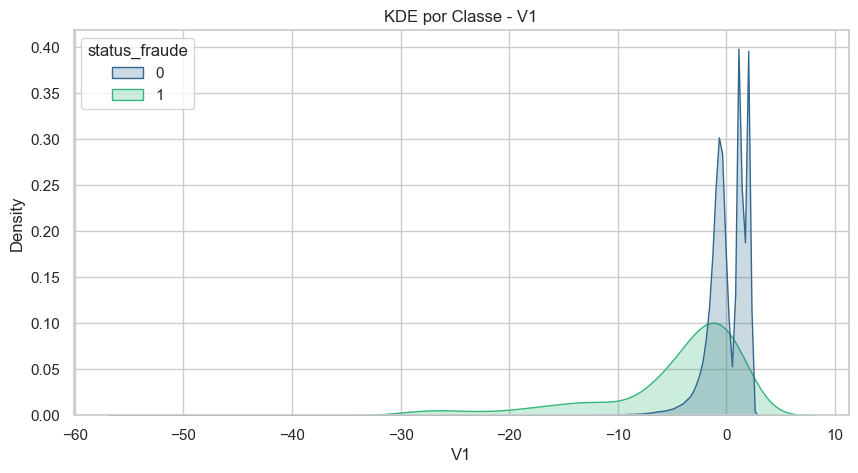

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


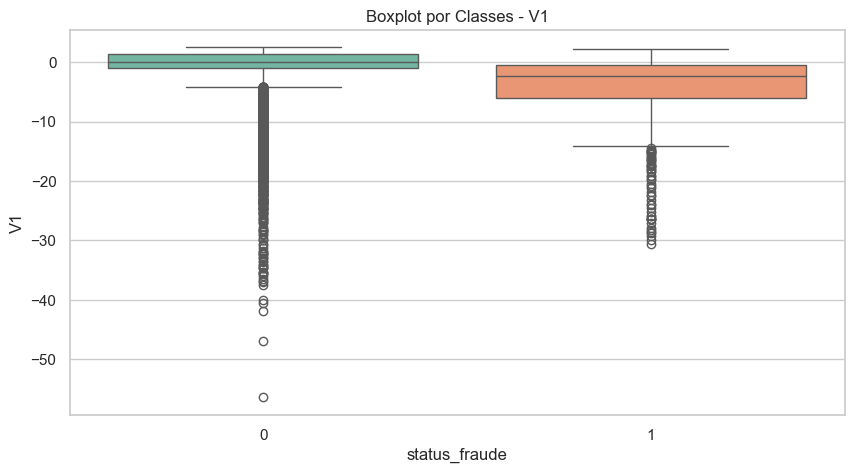

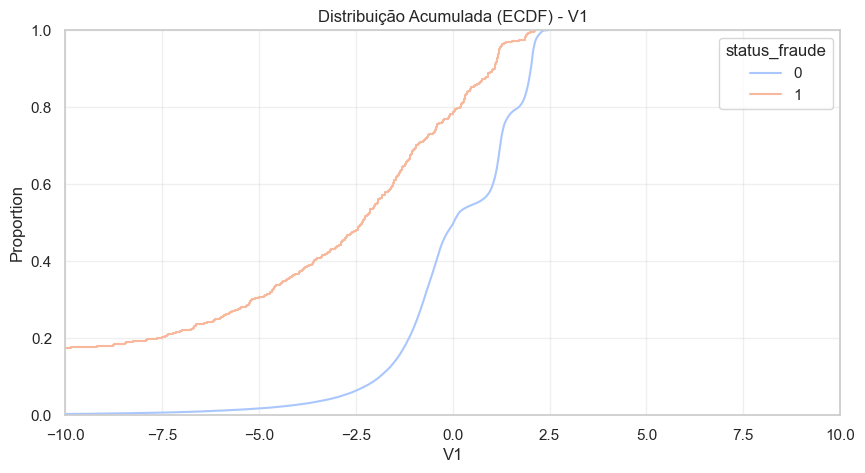

<Figure size 1000x500 with 0 Axes>

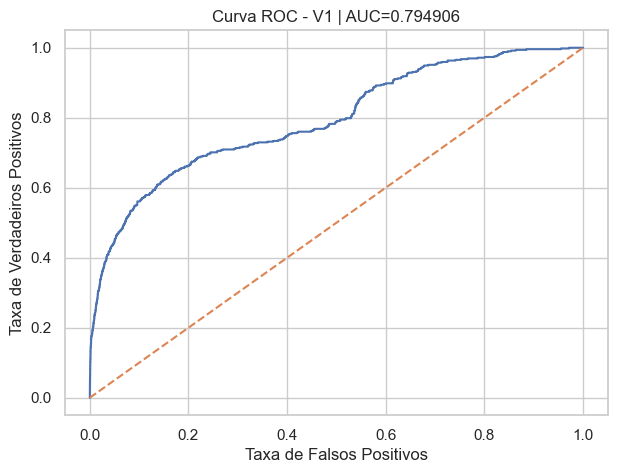

In [114]:
v1b = gerar_graficos_feature(
    df,
    feature='V1',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V2 

#### a) Descritiva e Comparação com target 

In [115]:
v2a =  analisar_feature_flexivel(df, 'V2',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.651309
min         -72.715728
25%          -0.598550
50%           0.065486
75%           0.803724
max          22.057729
Name: V2, dtype: object

[2] Dados faltantes em V2: 0


#### b) Análise Gráfica 

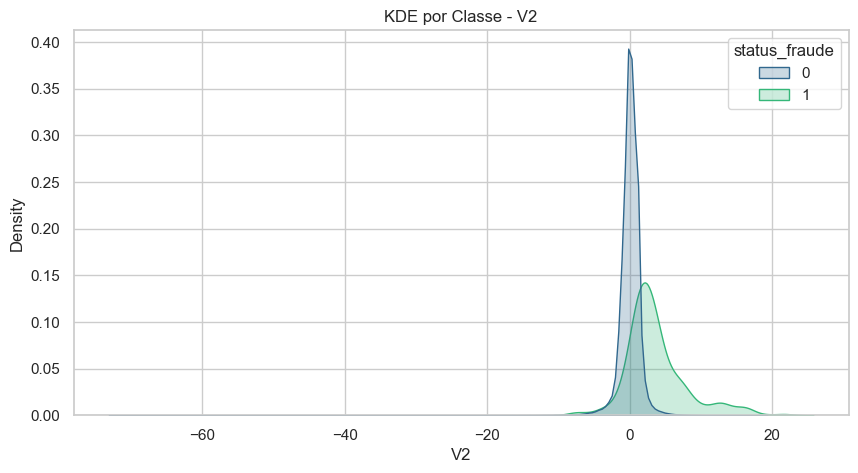

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


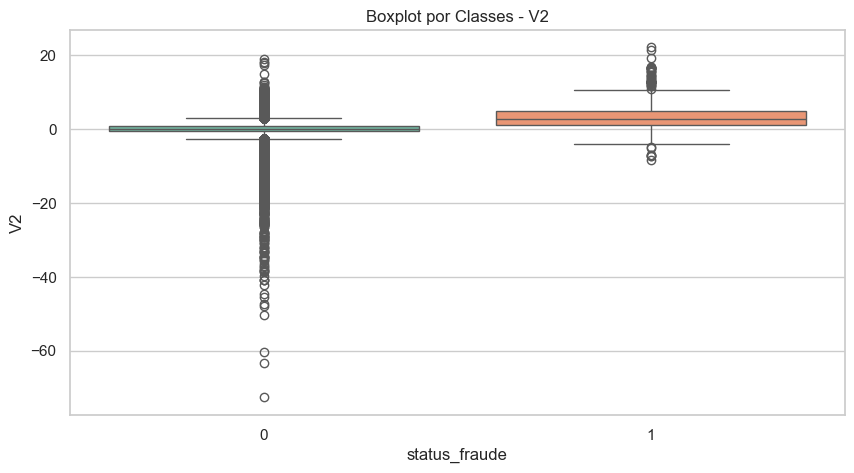

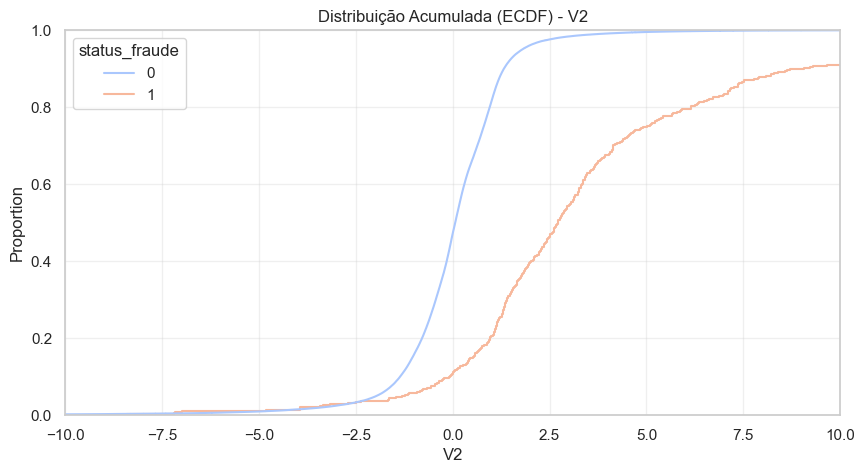

<Figure size 1000x500 with 0 Axes>

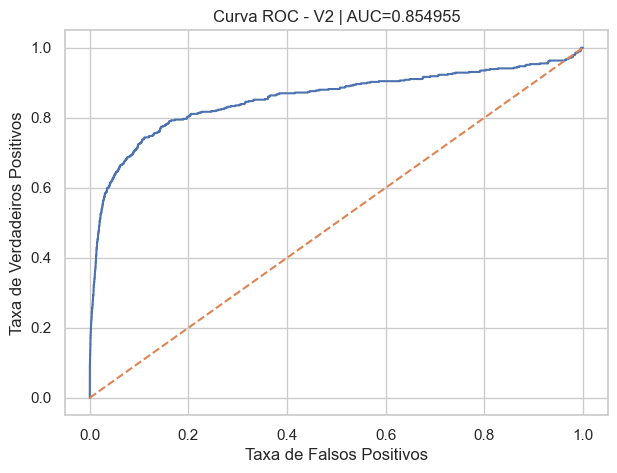

In [116]:

v2b = gerar_graficos_feature(
    df,
    feature='V2',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V3

#### a) Descritiva e Comparação com target 

In [117]:
v3a =  analisar_feature_flexivel(df, 'V3',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           1.516255
min         -48.325589
25%          -0.890365
50%           0.179846
75%           1.027196
max           9.382558
Name: V3, dtype: object

[2] Dados faltantes em V3: 0


#### b) Análise Gráfica 

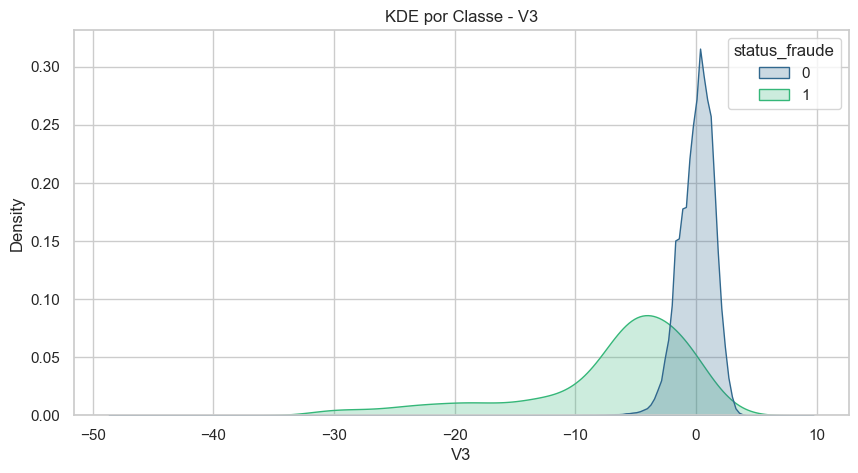

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


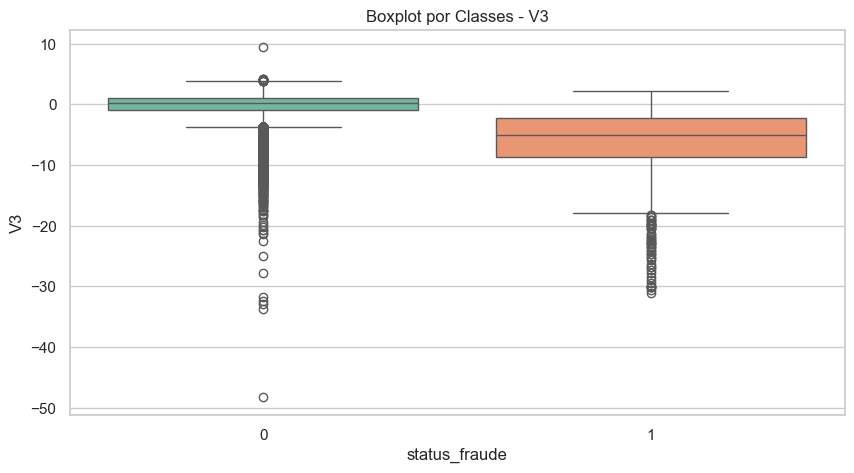

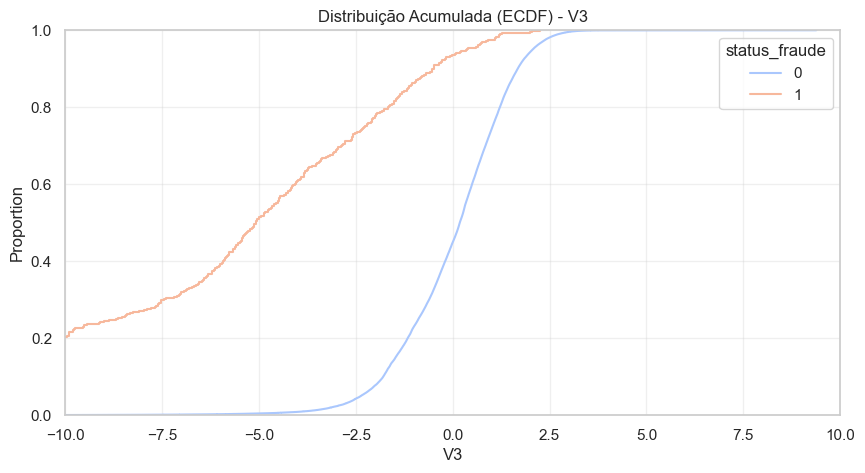

<Figure size 1000x500 with 0 Axes>

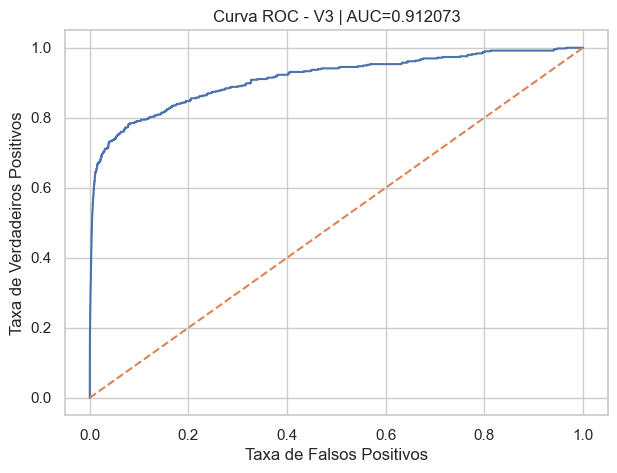

In [118]:

v3b = gerar_graficos_feature(
    df,
    feature='V3',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V4

#### a) Descritiva e Comparação com target 

In [119]:
v4a =  analisar_feature_flexivel(df, 'V4',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.415869
min          -5.683171
25%          -0.848640
50%          -0.019847
75%           0.743341
max          16.875344
Name: V4, dtype: object

[2] Dados faltantes em V4: 0


#### b) Análise Gráfica 

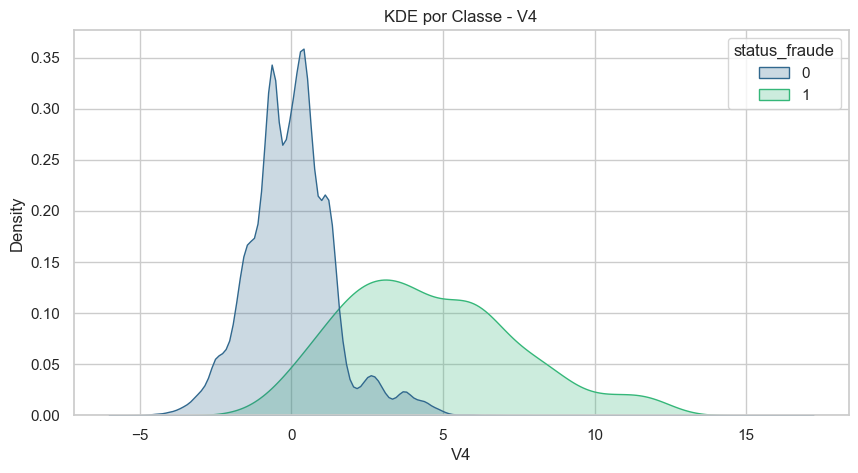

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


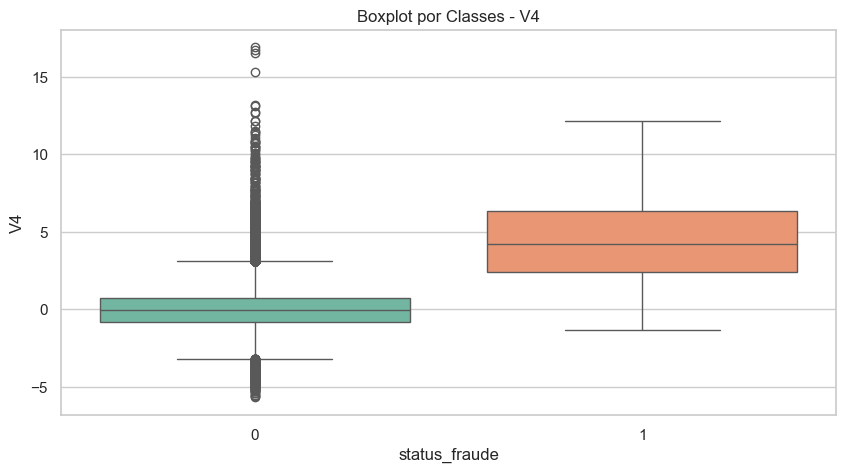

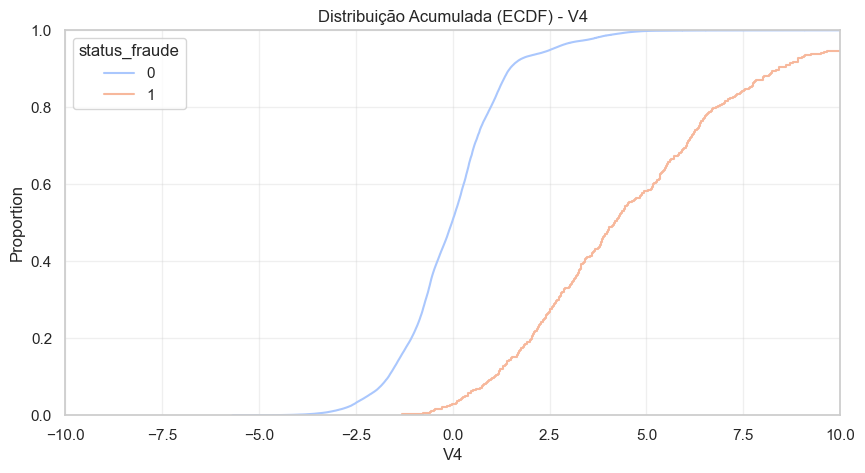

<Figure size 1000x500 with 0 Axes>

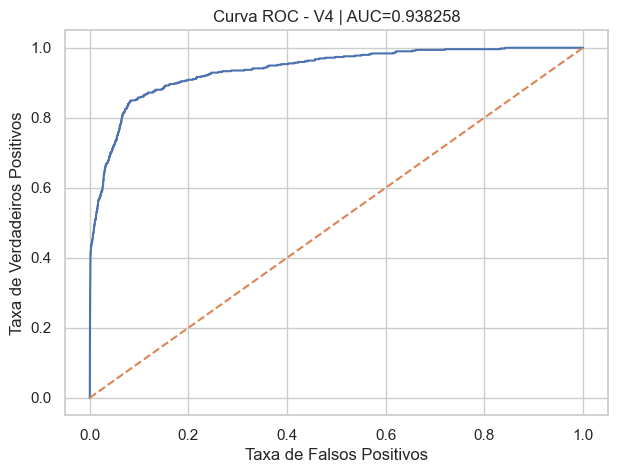

In [120]:

v4b = gerar_graficos_feature(
    df,
    feature='V4',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V5

#### a) Descritiva e Comparação com target 

In [121]:
v5a =  analisar_feature_flexivel(df, 'V5',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.380247
min        -113.743307
25%          -0.691597
50%          -0.054336
75%           0.611926
max          34.801666
Name: V5, dtype: object

[2] Dados faltantes em V5: 0


#### b) Análise Gráfica 

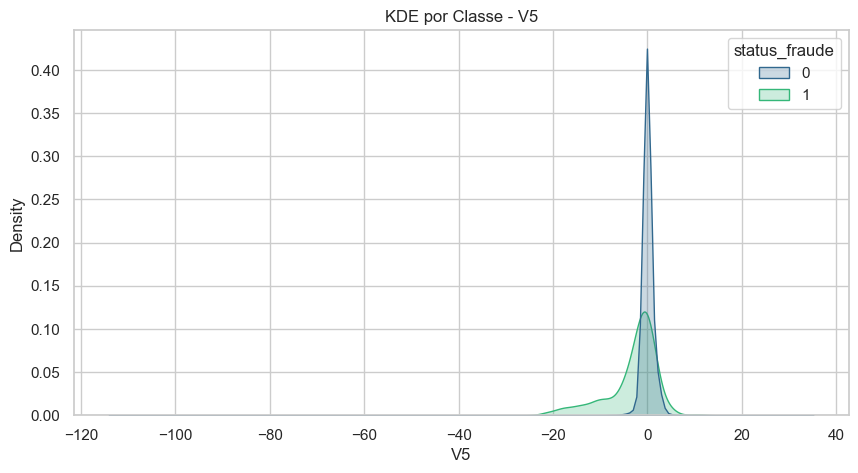

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


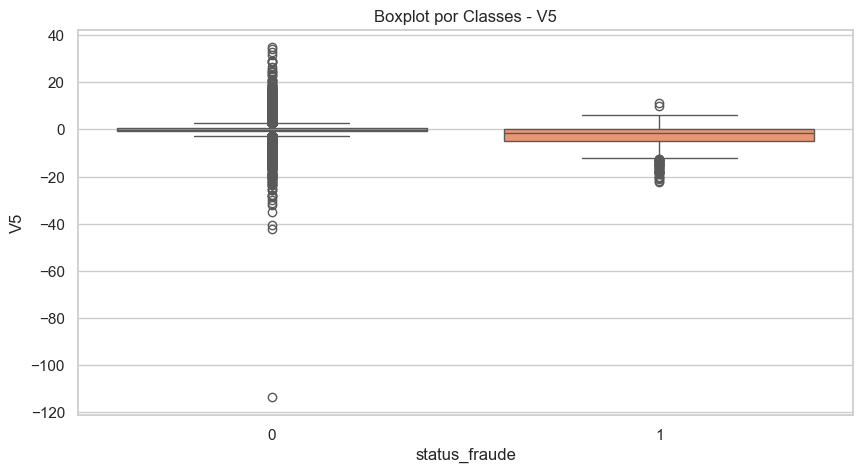

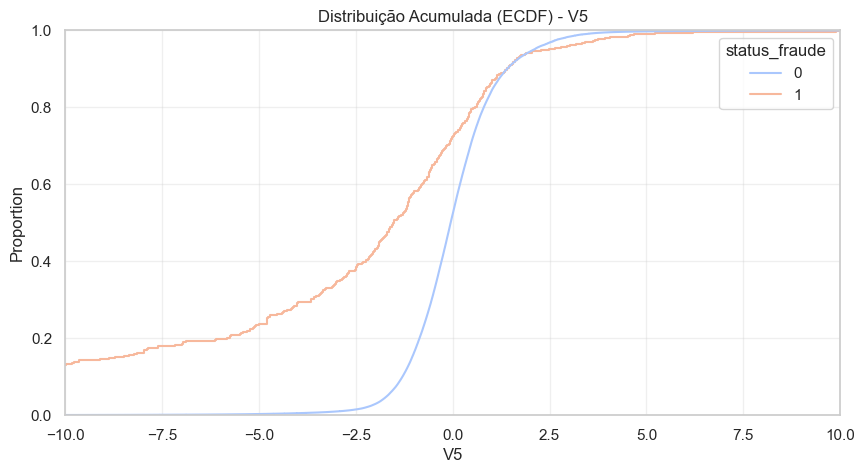

<Figure size 1000x500 with 0 Axes>

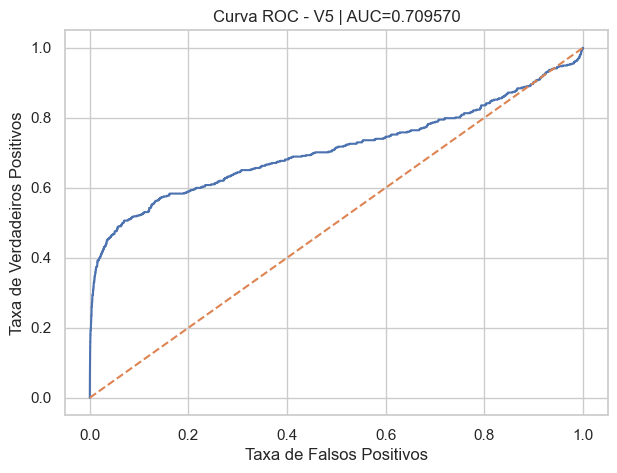

In [122]:

v5b = gerar_graficos_feature(
    df,
    feature='V5',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V6

#### a) Descritiva e Comparação com target 

In [123]:
v6a =  analisar_feature_flexivel(df, 'V6',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.332271
min         -26.160506
25%          -0.768296
50%          -0.274187
75%           0.398565
max          73.301626
Name: V6, dtype: object

[2] Dados faltantes em V6: 0


#### b) Análise Gráfica 

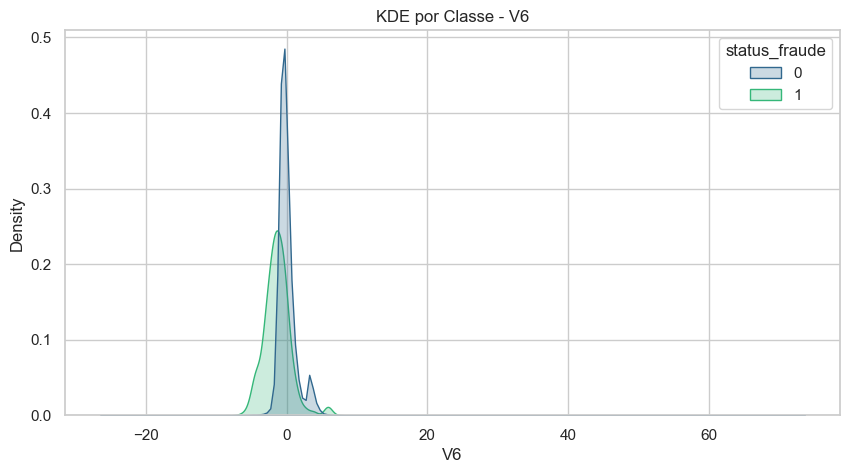

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


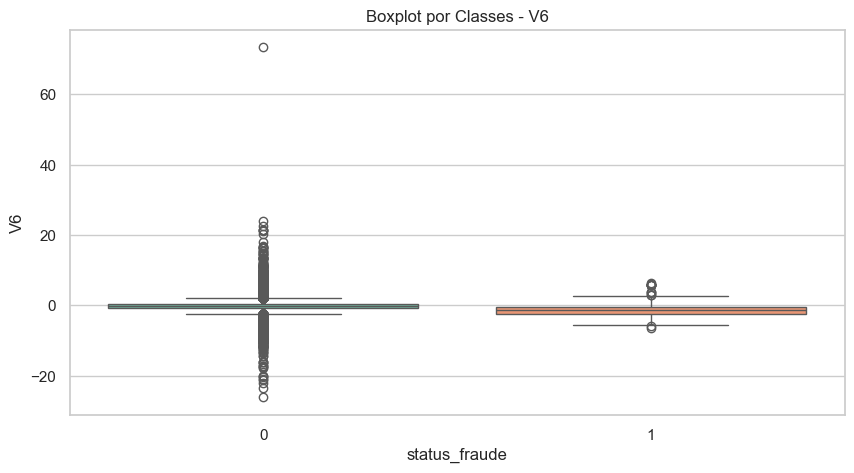

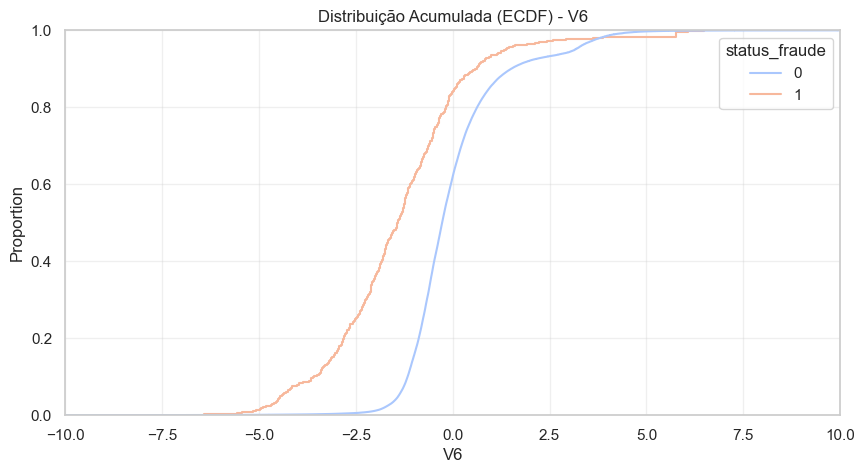

<Figure size 1000x500 with 0 Axes>

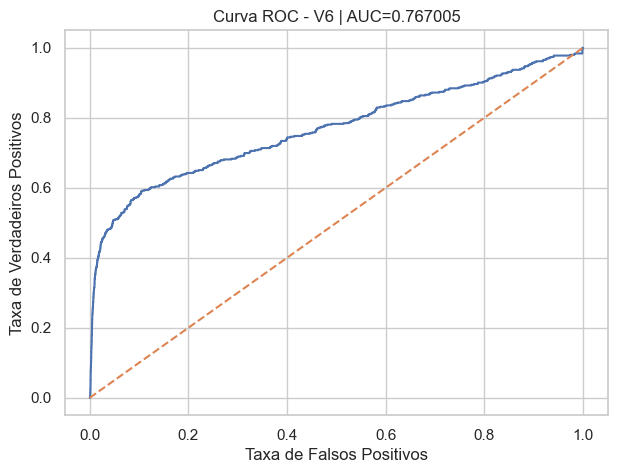

In [124]:

v6b = gerar_graficos_feature(
    df,
    feature='V6',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V7

#### a) Descritiva e Comparação com target 

In [125]:
v7a =  analisar_feature_flexivel(df, 'V7',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           1.237094
min         -43.557242
25%          -0.554076
50%           0.040103
75%           0.570436
max         120.589494
Name: V7, dtype: object

[2] Dados faltantes em V7: 0


#### b) Análise Gráfica 

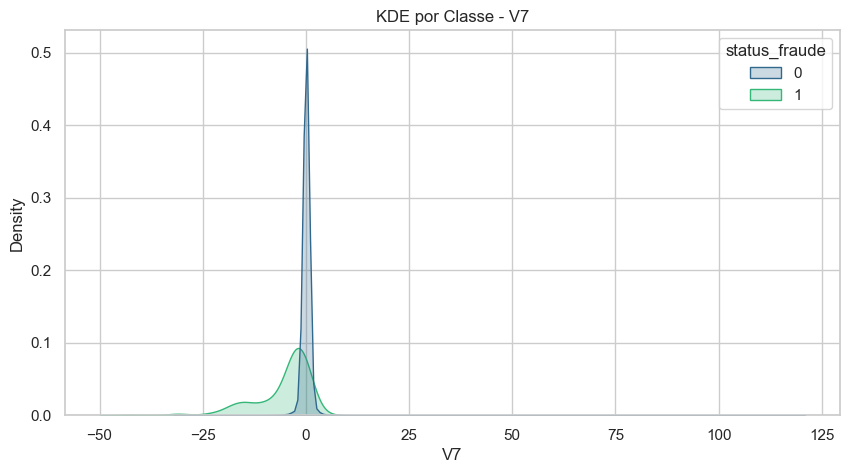

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


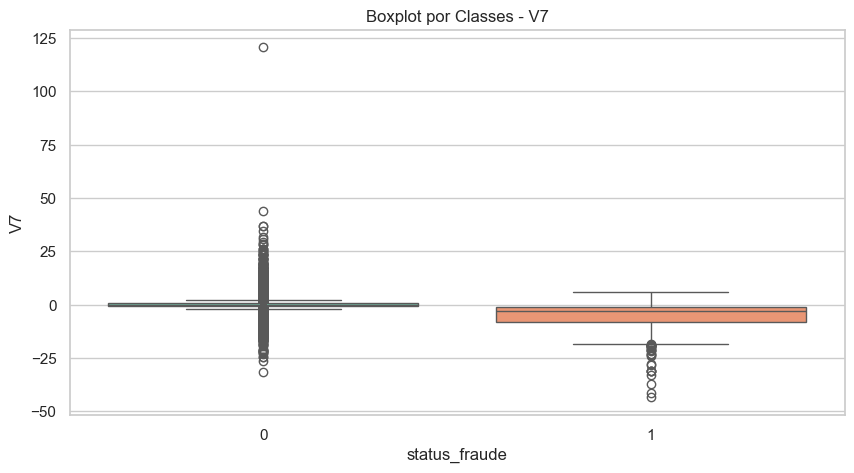

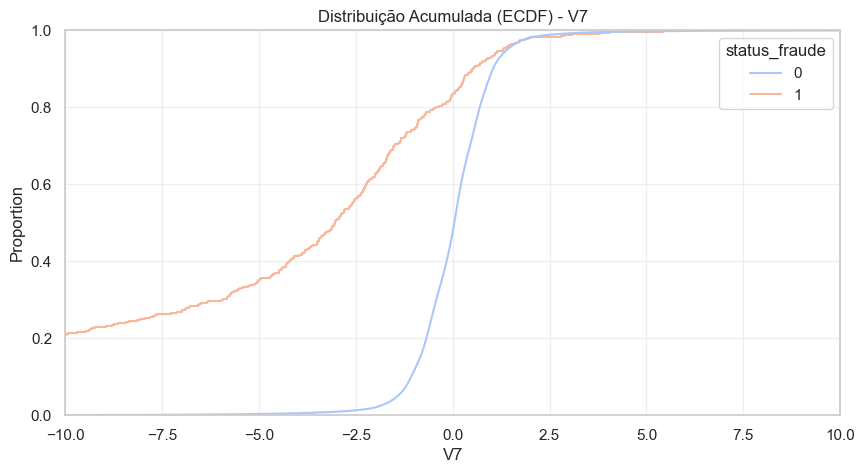

<Figure size 1000x500 with 0 Axes>

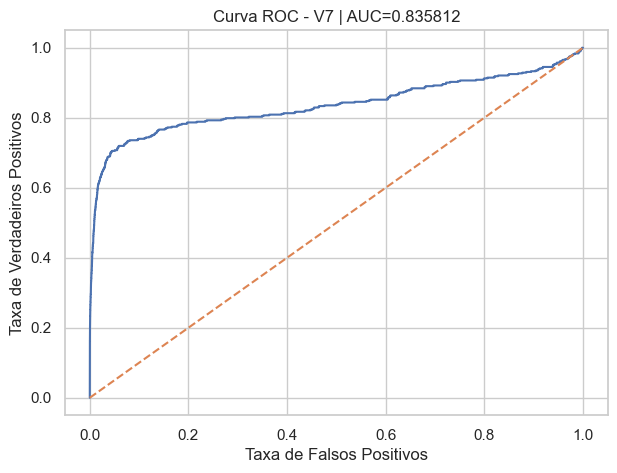

In [126]:

v7b = gerar_graficos_feature(
    df,
    feature='V7',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V8

#### a) Descritiva e Comparação com target 

In [127]:
v8a =  analisar_feature_flexivel(df, 'V8',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.194353
min         -73.216718
25%          -0.208630
50%           0.022358
75%           0.327346
max          20.007208
Name: V8, dtype: object

[2] Dados faltantes em V8: 0


#### b) Análise Gráfica 

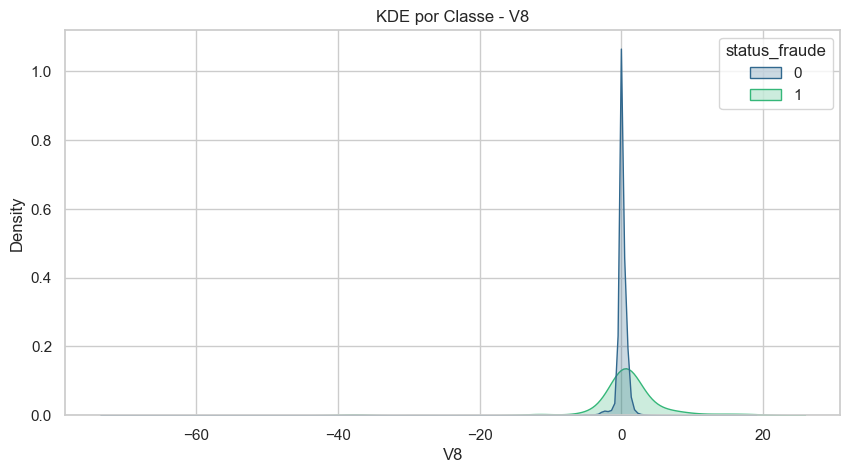

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


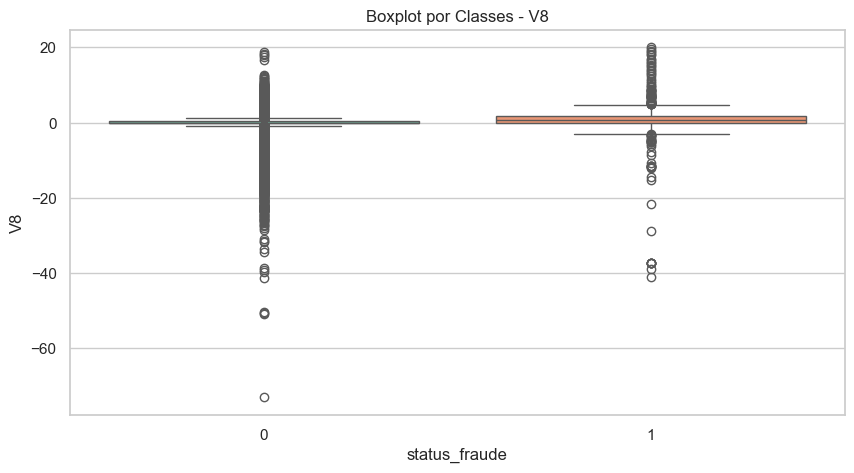

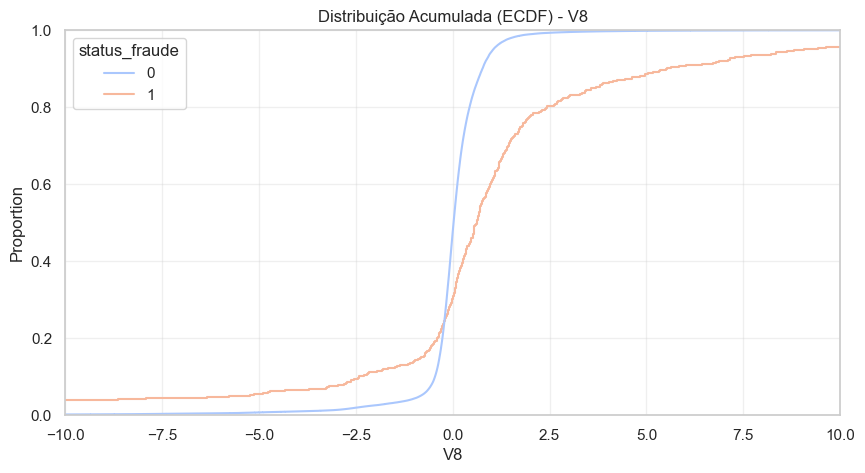

<Figure size 1000x500 with 0 Axes>

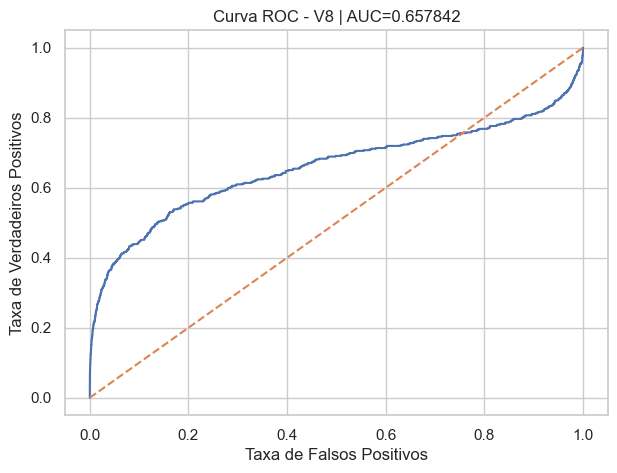

In [128]:
v8b = gerar_graficos_feature(
    df,
    feature='V8',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V9

#### a) Descritiva e Comparação com target 

In [129]:
v9a =  analisar_feature_flexivel(df, 'V9',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           1.098632
min         -13.434066
25%          -0.643098
50%          -0.051429
75%           0.597139
max          15.594995
Name: V9, dtype: object

[2] Dados faltantes em V9: 0


#### b) Análise Gráfica 

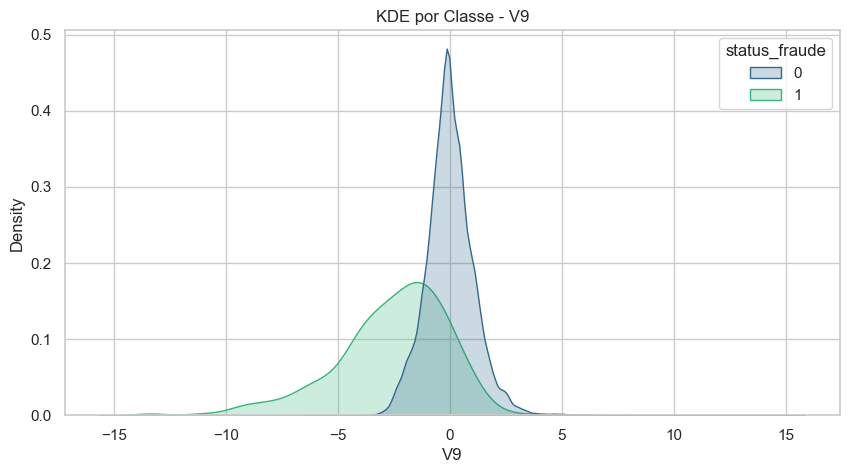

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


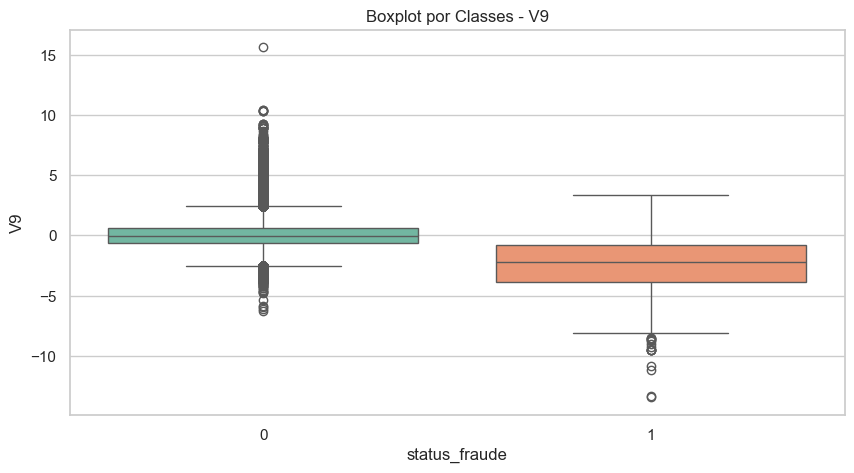

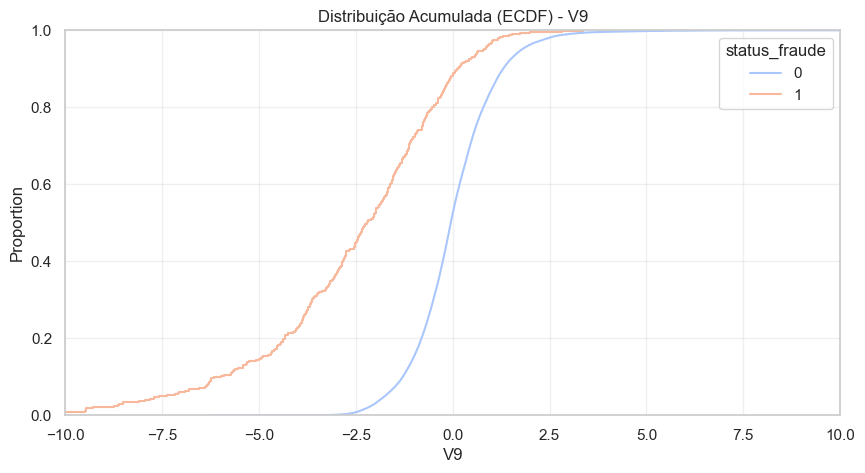

<Figure size 1000x500 with 0 Axes>

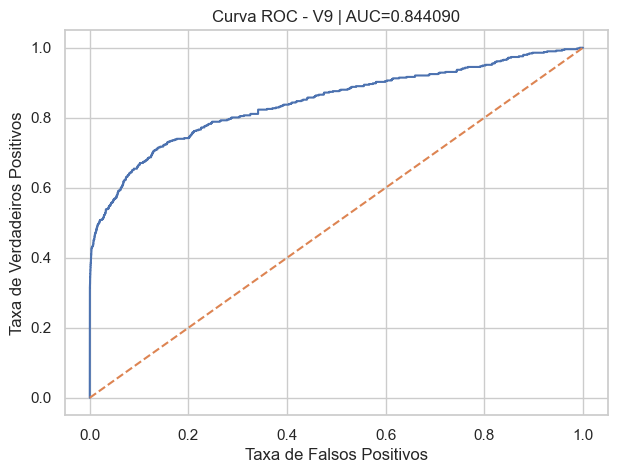

In [130]:
v9b = gerar_graficos_feature(
    df,
    feature='V9',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)


### ESTUDO SOBRE V10

#### a) Descritiva e Comparação com target 

In [131]:
v10a =  analisar_feature_flexivel(df, 'V10',target_name='status_fraude', alpha= valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.088850
min         -24.588262
25%          -0.535426
50%          -0.092917
75%           0.453923
max          23.745136
Name: V10, dtype: object

[2] Dados faltantes em V10: 0


#### b) Análise Gráfica 

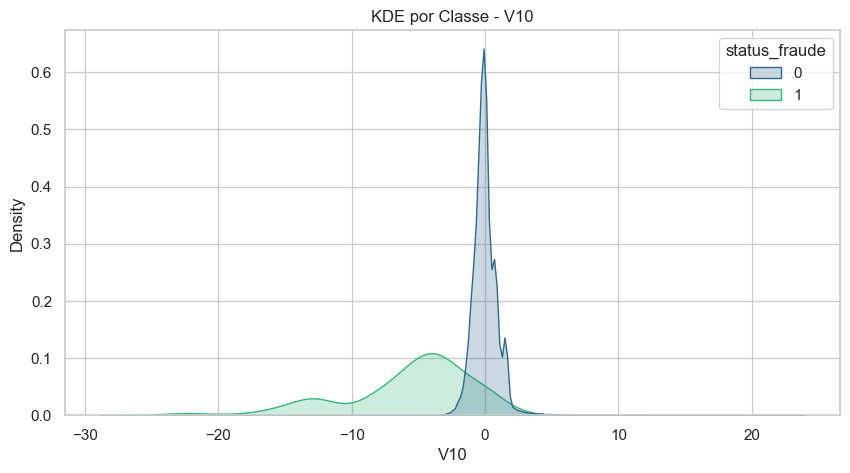

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


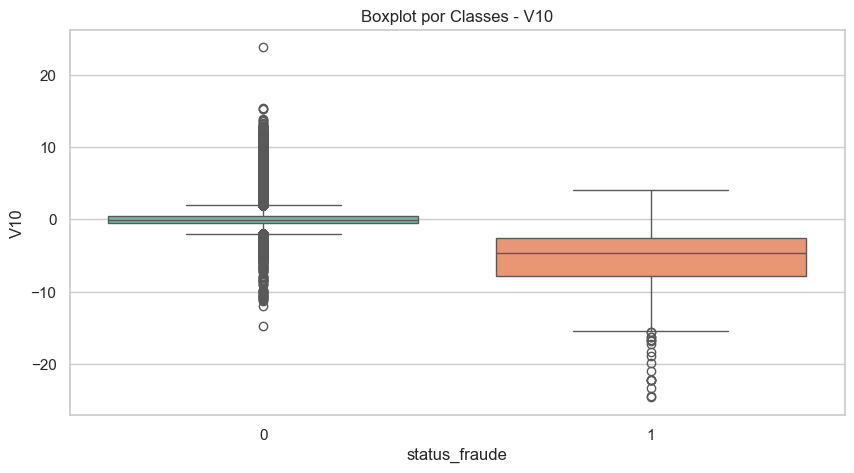

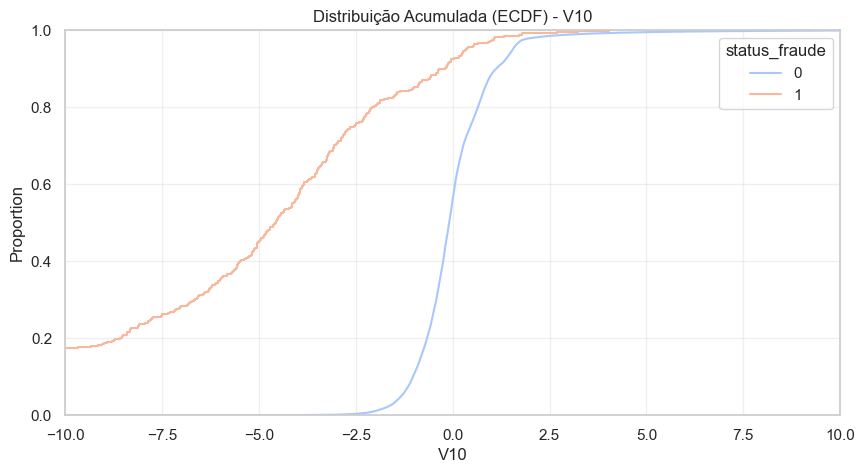

<Figure size 1000x500 with 0 Axes>

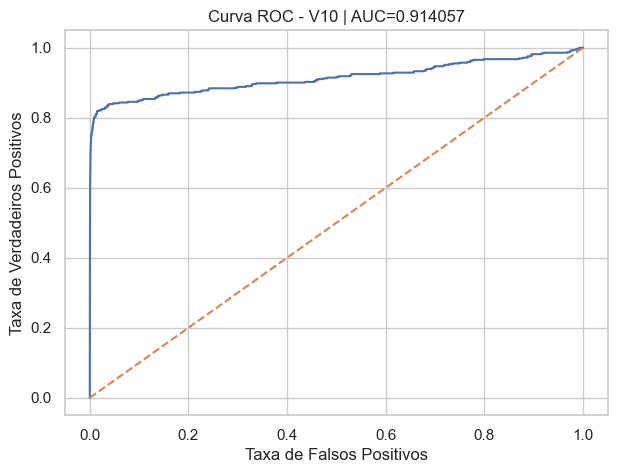

In [132]:
v10b = gerar_graficos_feature(
    df,
    feature='V10',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V11

#### a) Descritiva e Comparação com target 

In [133]:
v11a =  analisar_feature_flexivel(df, 'V11',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           1.020713
min          -4.797473
25%          -0.762494
50%          -0.032757
75%           0.739593
max          12.018913
Name: V11, dtype: object

[2] Dados faltantes em V11: 0


#### b) Análise Gráfica 

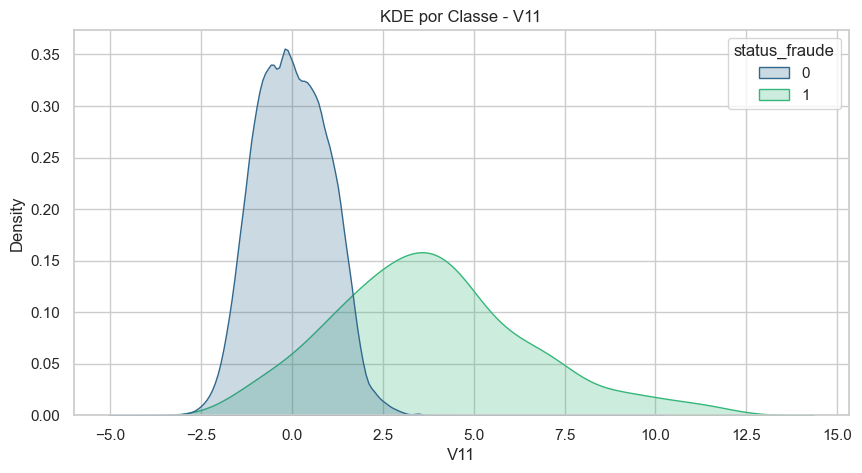

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


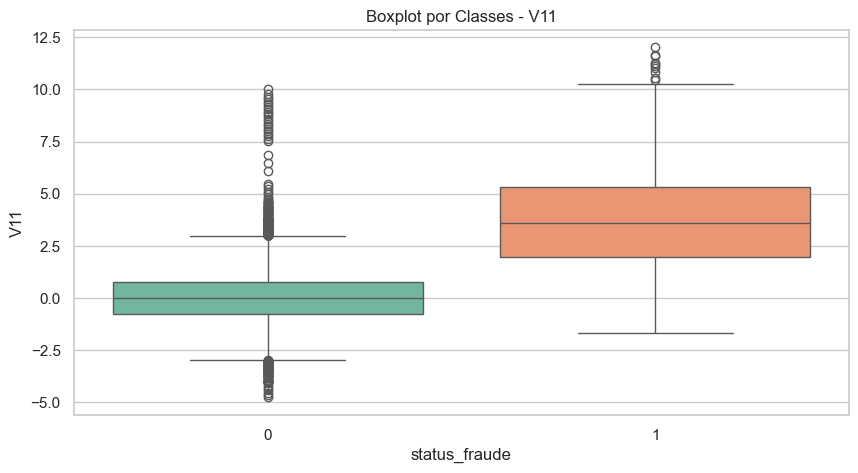

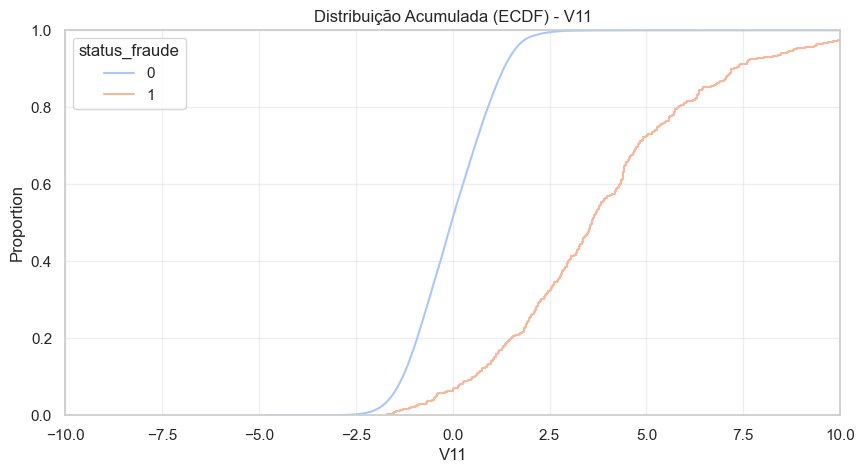

<Figure size 1000x500 with 0 Axes>

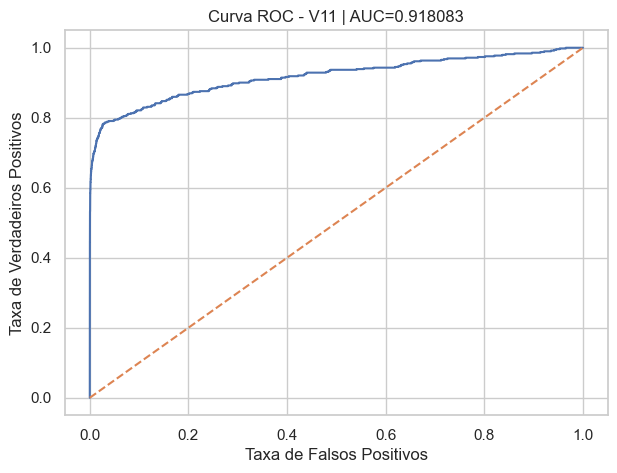

In [134]:
v11b = gerar_graficos_feature(
    df,
    feature='V11',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V12

#### a) Descritiva e Comparação com target 

In [135]:
v12a =  analisar_feature_flexivel(df, 'V12',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           0.999201
min         -18.683715
25%          -0.405571
50%           0.140033
75%           0.618238
max           7.848392
Name: V12, dtype: object

[2] Dados faltantes em V12: 0


#### b) Análise Gráfica 

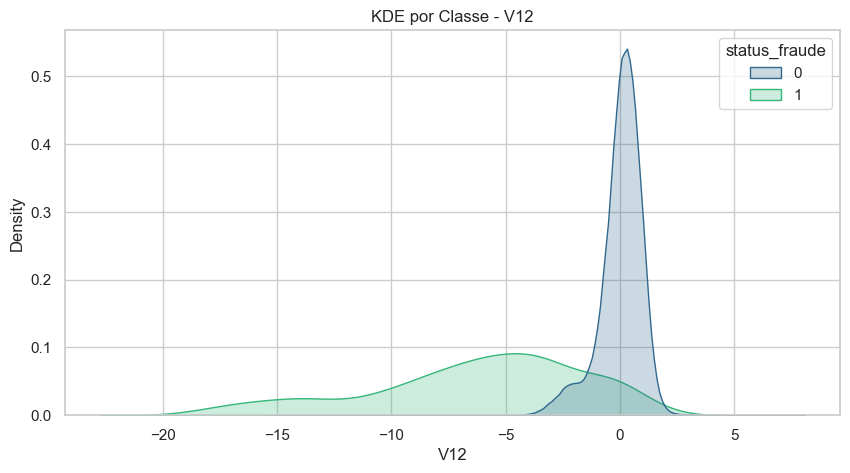

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


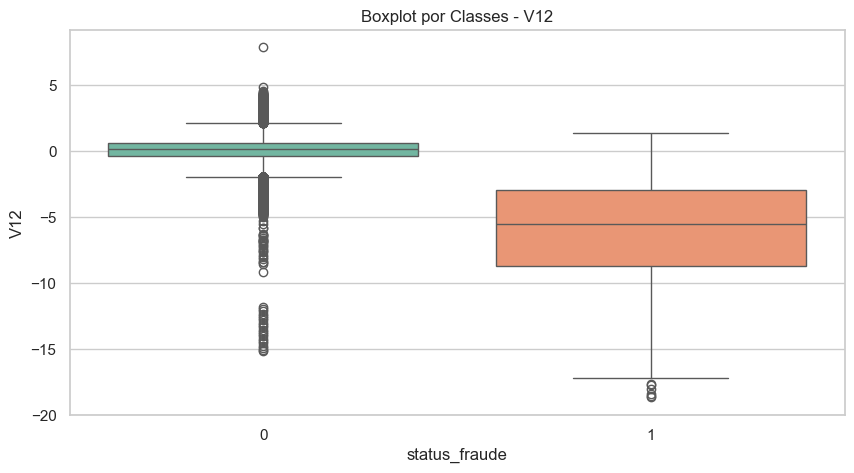

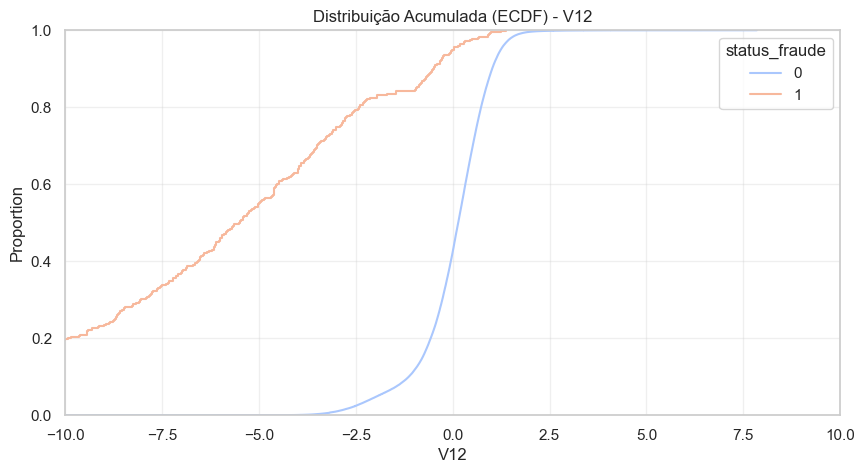

<Figure size 1000x500 with 0 Axes>

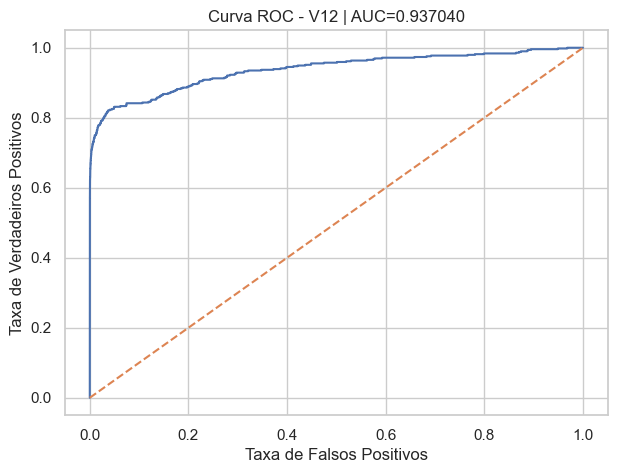

In [136]:
v12b = gerar_graficos_feature(
    df,
    feature='V12',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V13

#### a) Descritiva e Comparação com target 

In [137]:
v13a =  analisar_feature_flexivel(df, 'V13',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.995274
min          -5.791881
25%          -0.648539
50%          -0.013568
75%           0.662505
max           7.126883
Name: V13, dtype: object

[2] Dados faltantes em V13: 0


#### b) Análise Gráfica 

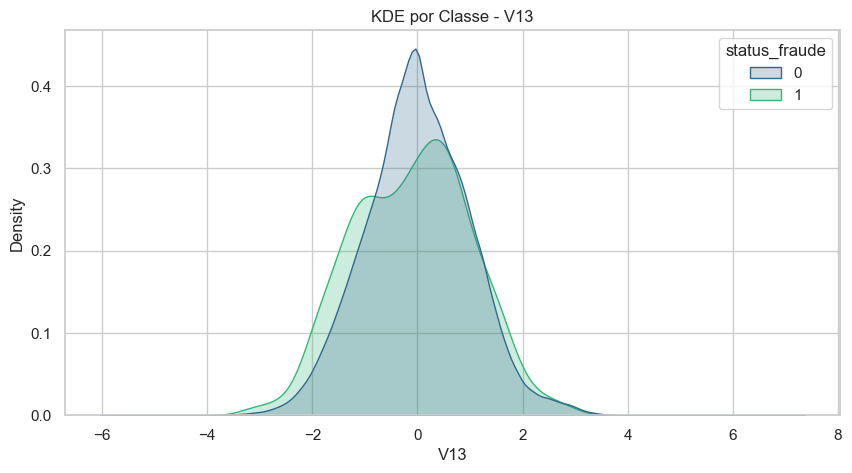

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


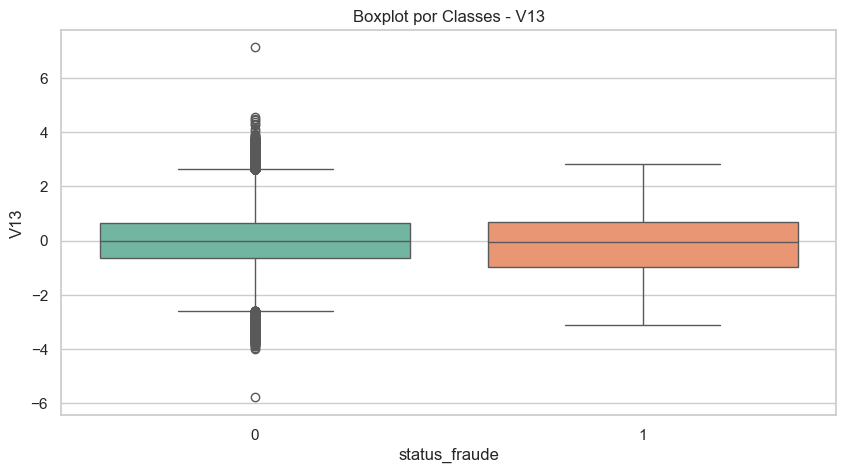

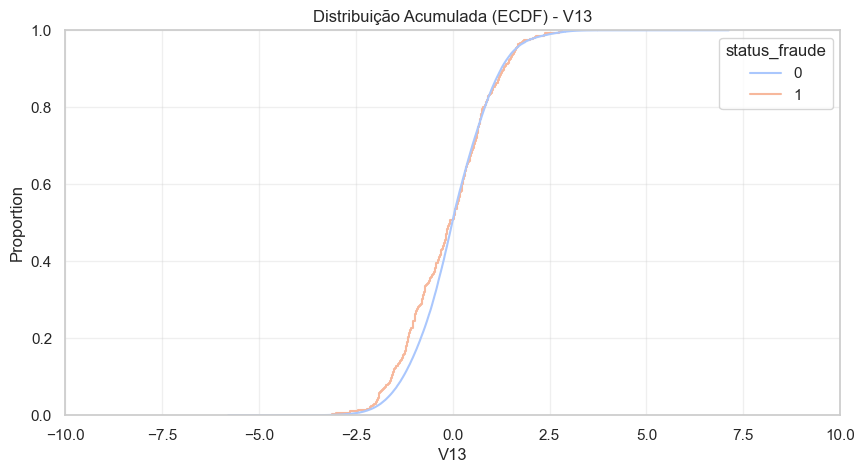

<Figure size 1000x500 with 0 Axes>

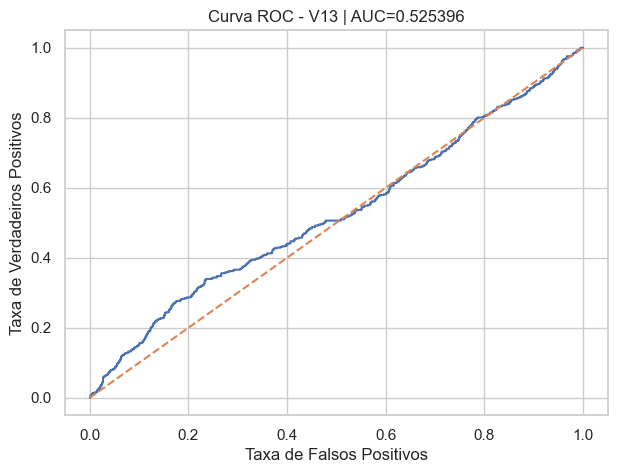

In [138]:
v13b = gerar_graficos_feature(
    df,
    feature='V13',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V14

#### a) Descritiva e Comparação com target 

In [139]:
v14 =  analisar_feature_flexivel(df, 'V14',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.958596
min         -19.214325
25%          -0.425574
50%           0.050601
75%           0.493150
max          10.526766
Name: V14, dtype: object

[2] Dados faltantes em V14: 0


#### b) Análise Gráfica 

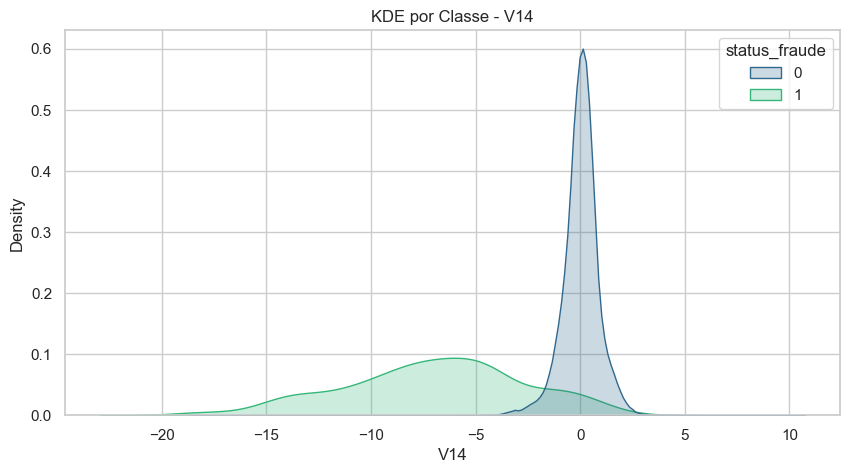

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


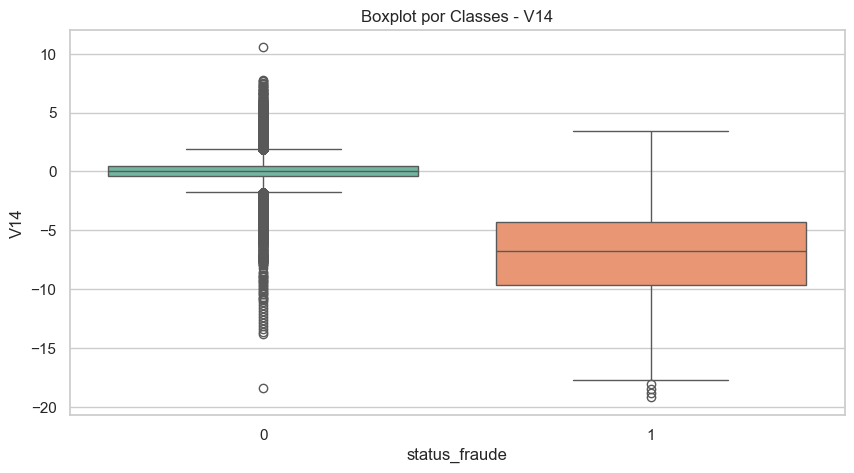

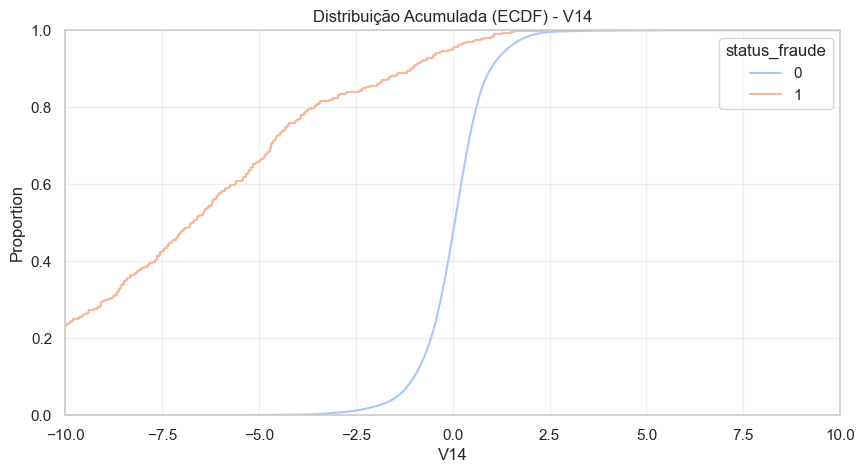

<Figure size 1000x500 with 0 Axes>

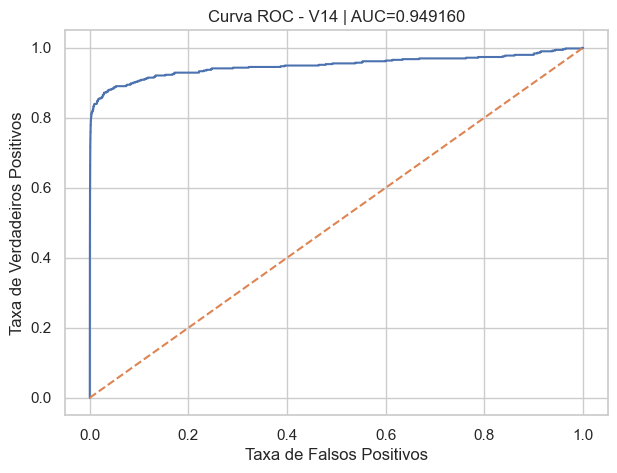

In [140]:
v14b = gerar_graficos_feature(
    df,
    feature='V14',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V15

#### a) Descritiva e Comparação com target 

In [141]:
v15a =  analisar_feature_flexivel(df, 'V15',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.915316
min          -4.498945
25%          -0.582884
50%           0.048072
75%           0.648821
max           8.877742
Name: V15, dtype: object

[2] Dados faltantes em V15: 0


#### b) Análise Gráfica 

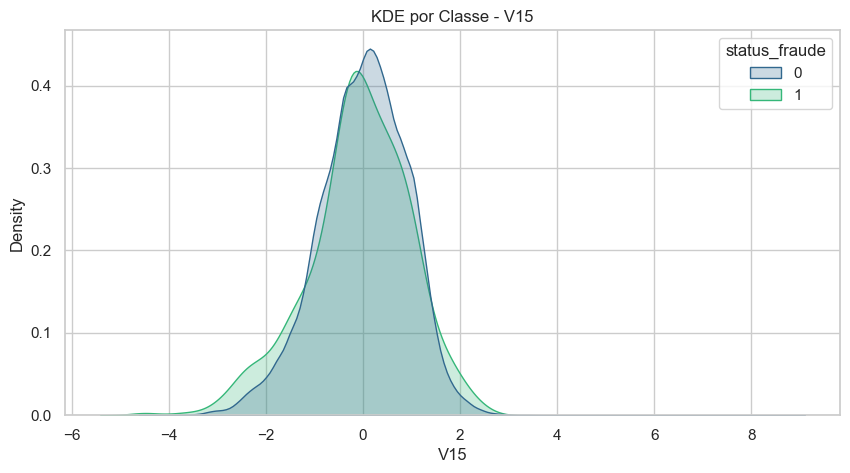

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


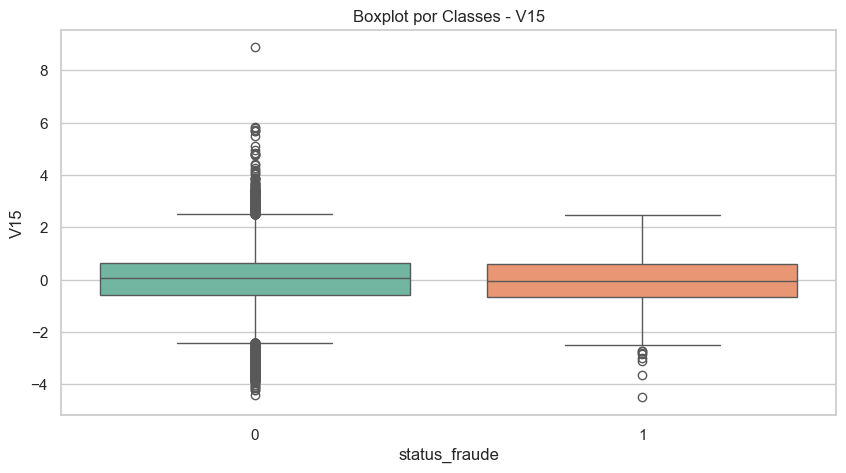

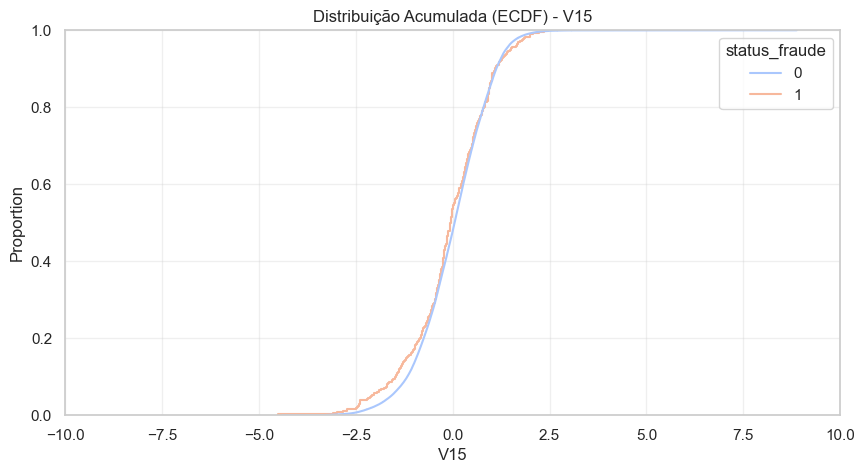

<Figure size 1000x500 with 0 Axes>

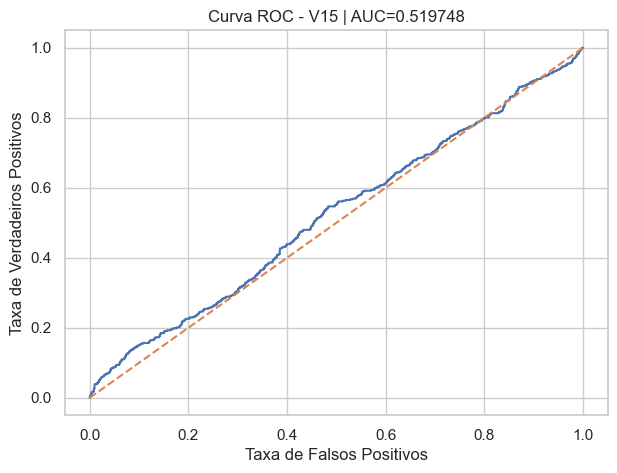

In [142]:
v15b = gerar_graficos_feature(
    df,
    feature='V15',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V16

#### a) Descritiva e Comparação com target 

In [143]:
v16a =  analisar_feature_flexivel(df, 'V16',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.876253
min         -14.129855
25%          -0.468037
50%           0.066413
75%           0.523296
max          17.315112
Name: V16, dtype: object

[2] Dados faltantes em V16: 0


#### b) Análise Gráfica 

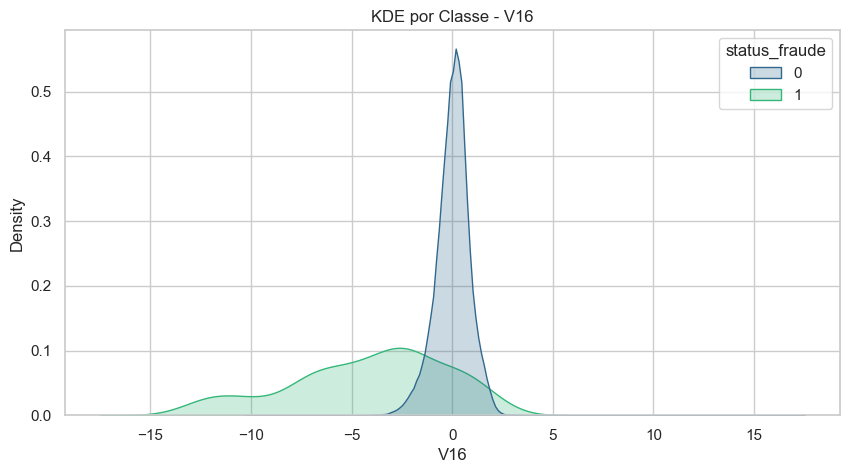

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


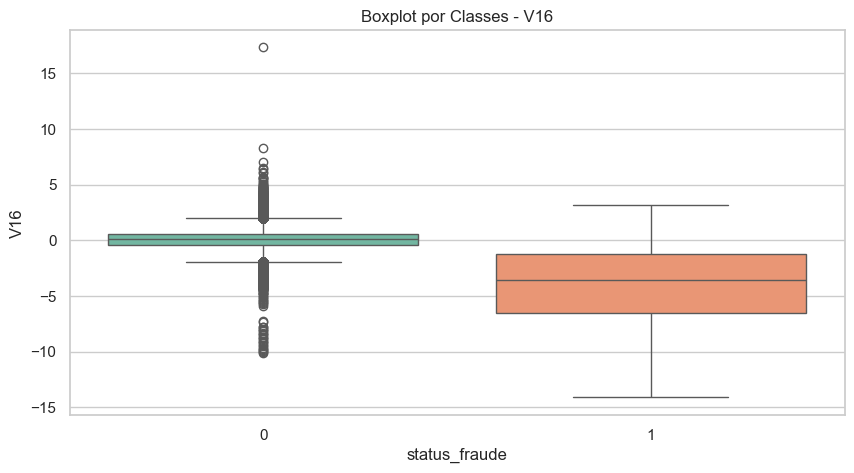

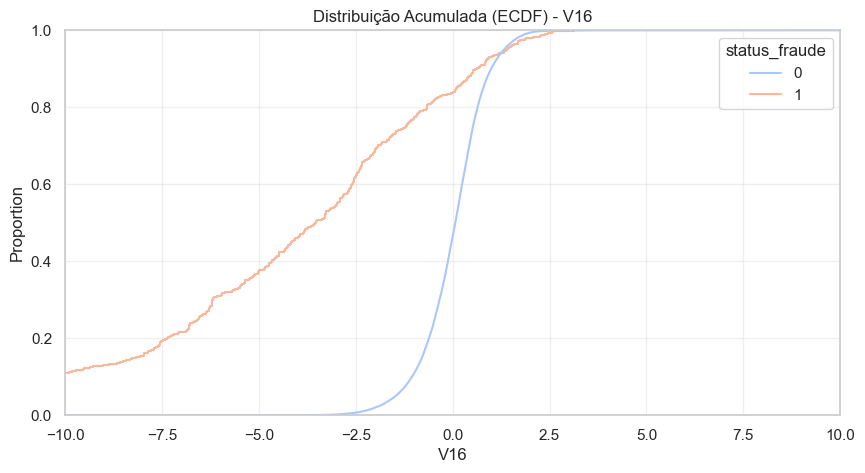

<Figure size 1000x500 with 0 Axes>

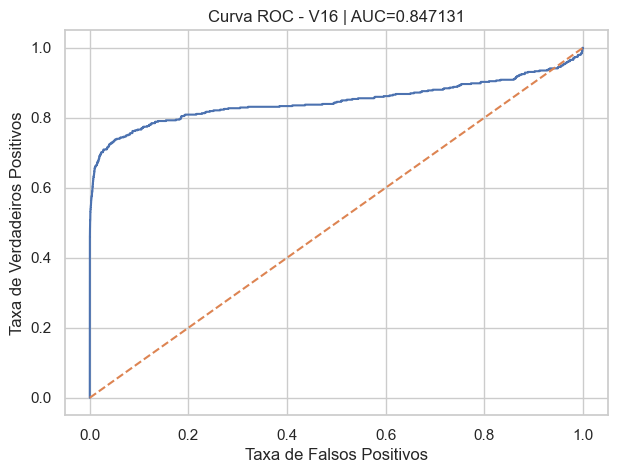

In [144]:
v16b = gerar_graficos_feature(
    df,
    feature='V16',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V17

#### a) Descritiva e Comparação com target 

In [145]:
v17a =  analisar_feature_flexivel(df, 'V17',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           0.849337
min         -25.162799
25%          -0.483748
50%          -0.065676
75%           0.399675
max           9.253526
Name: V17, dtype: object

[2] Dados faltantes em V17: 0


#### b) Análise Gráfica 

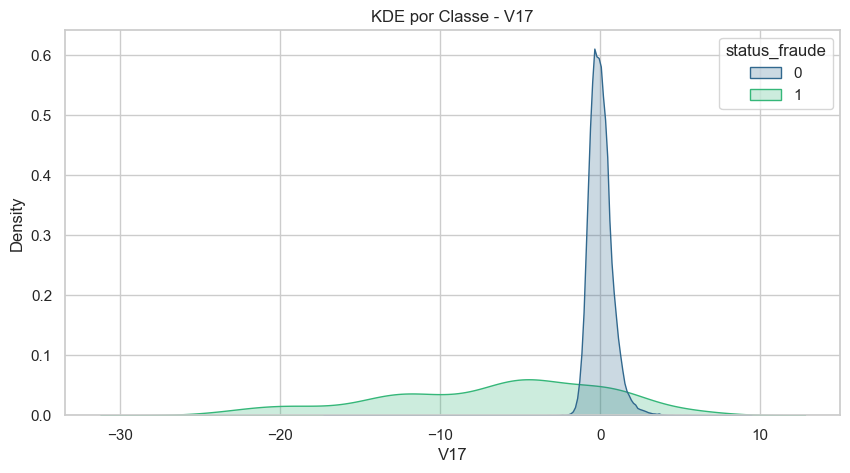

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


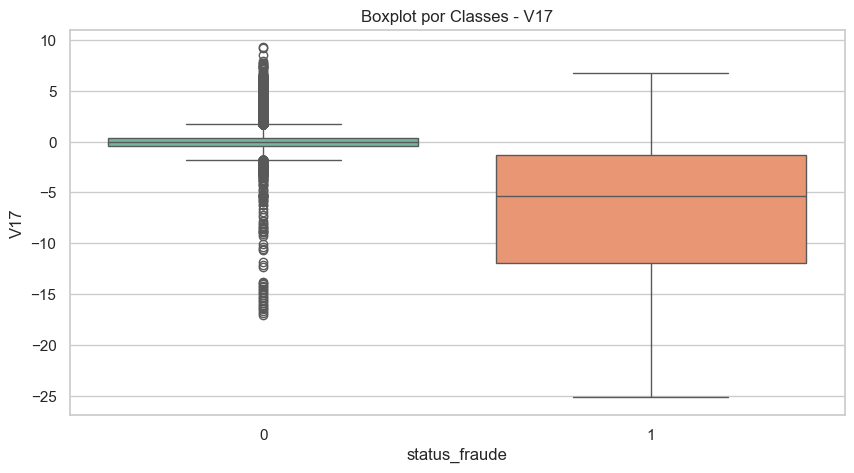

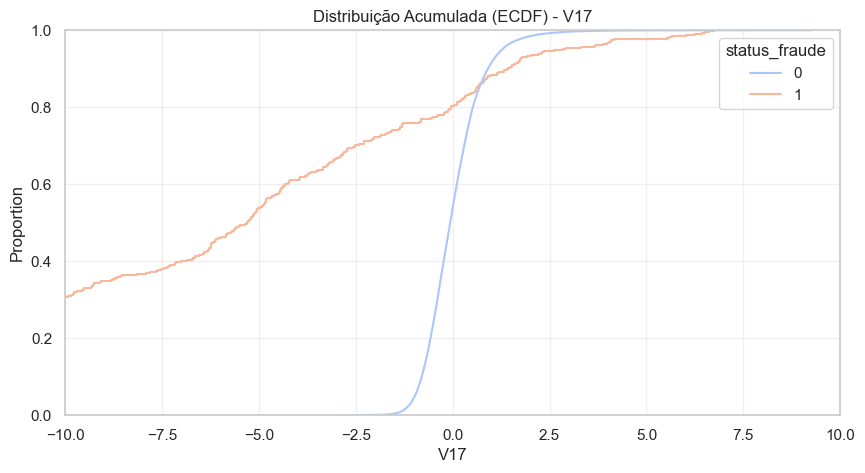

<Figure size 1000x500 with 0 Axes>

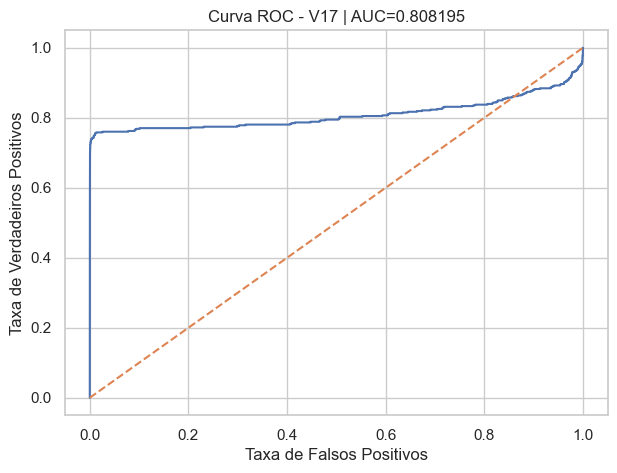

In [146]:
v17b = gerar_graficos_feature(
    df,
    feature='V17',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V18

#### a) Descritiva e Comparação com target 

In [147]:
v18a =  analisar_feature_flexivel(df, 'V18',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.838176
min          -9.498746
25%          -0.498850
50%          -0.003636
75%           0.500807
max           5.041069
Name: V18, dtype: object

[2] Dados faltantes em V18: 0


#### b) Análise Gráfica 

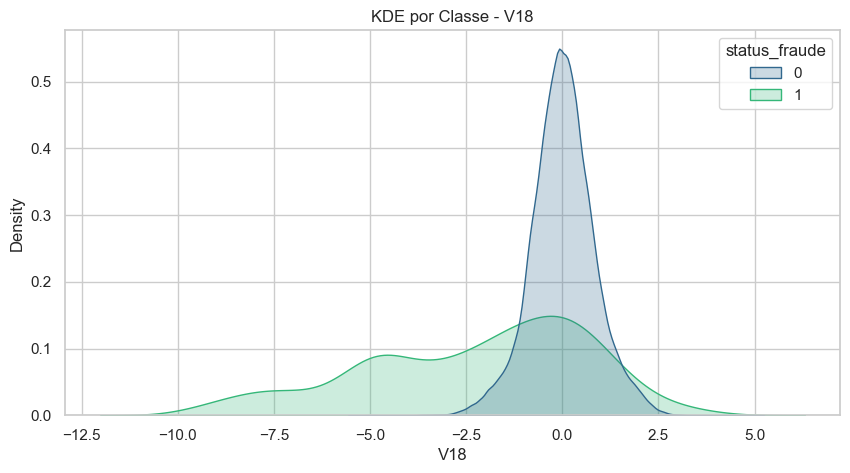

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


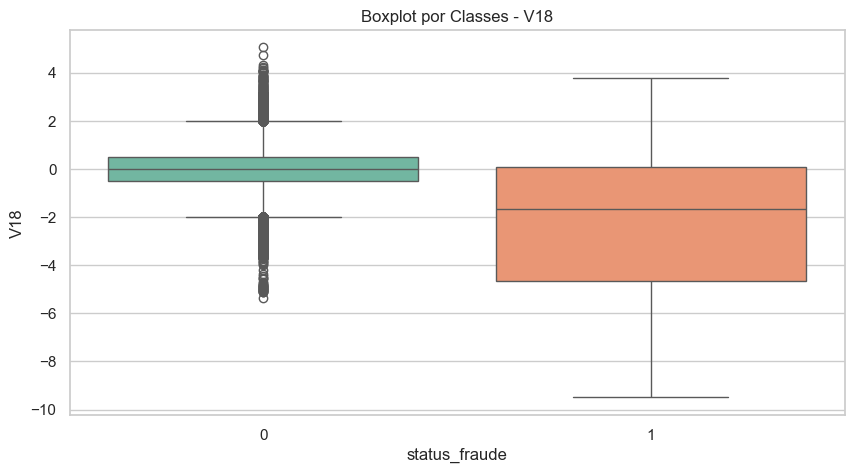

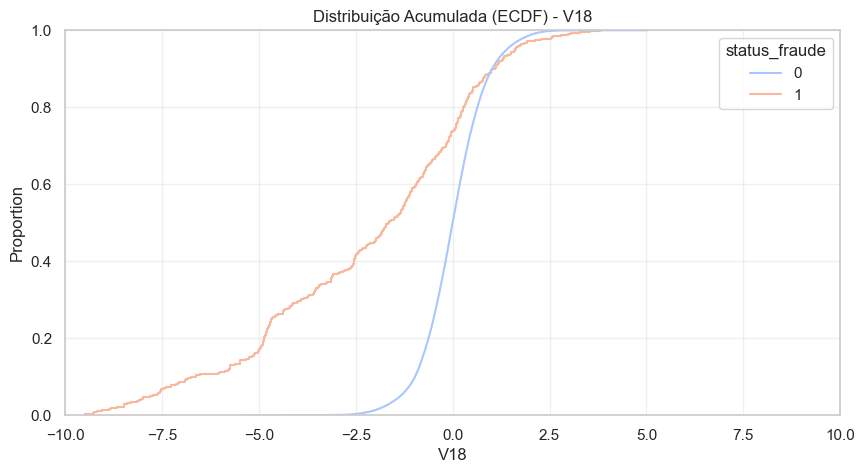

<Figure size 1000x500 with 0 Axes>

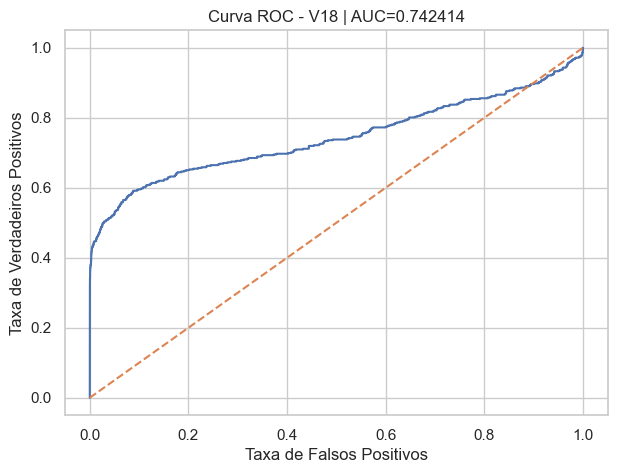

In [148]:
v18b = gerar_graficos_feature(
    df,
    feature='V18',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V19

#### a) Descritiva e Comparação com target 

In [149]:
v19a =  analisar_feature_flexivel(df, 'V19',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.814041
min          -7.213527
25%          -0.456299
50%           0.003735
75%           0.458949
max           5.591971
Name: V19, dtype: object

[2] Dados faltantes em V19: 0


#### b) Análise Gráfica 

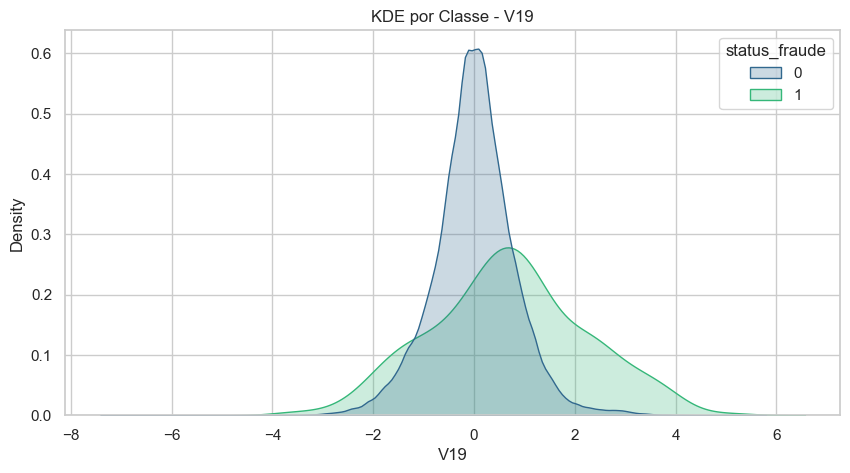

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


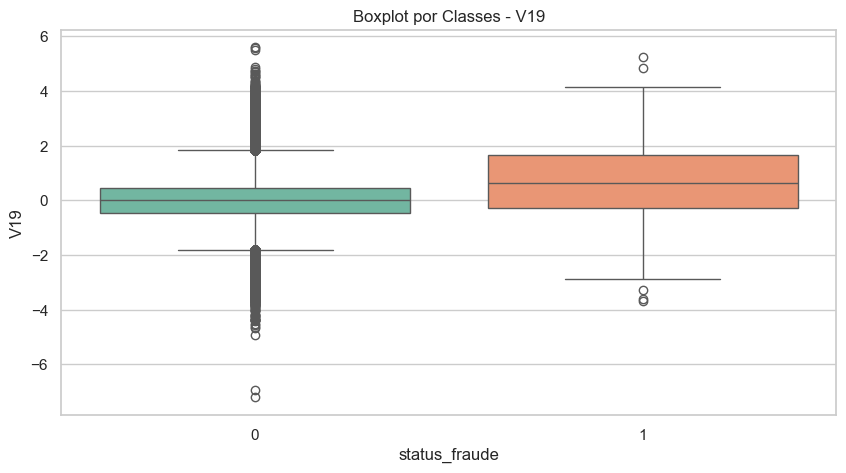

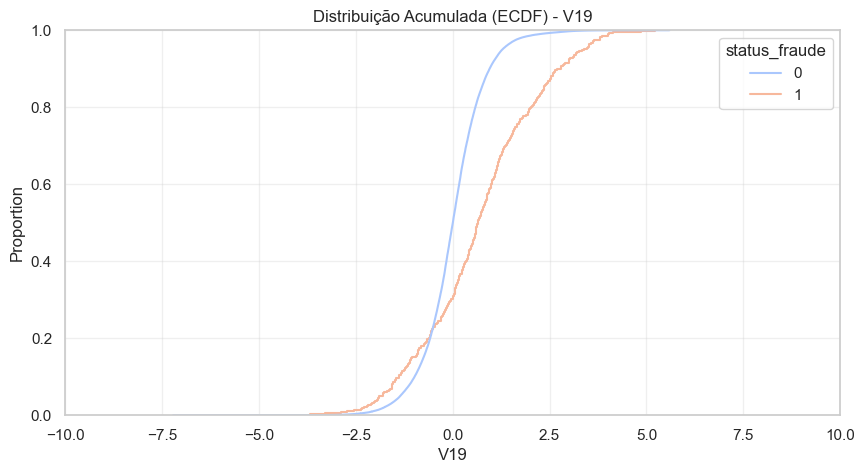

<Figure size 1000x500 with 0 Axes>

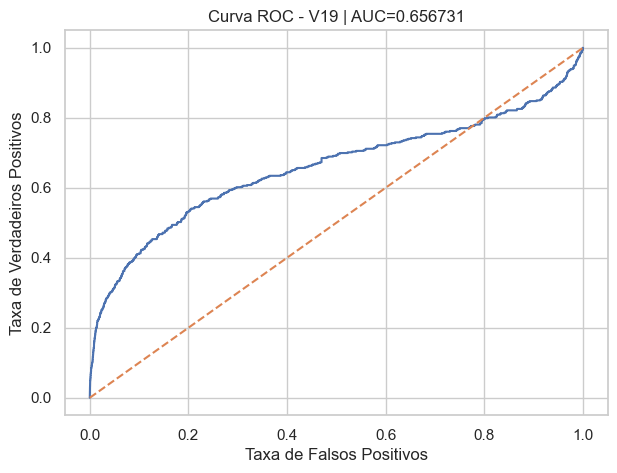

In [150]:
v19b = gerar_graficos_feature(
    df,
    feature='V19',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V20

#### a) Descritiva e Comparação com target 

In [151]:
v20a =  analisar_feature_flexivel(df, 'V20',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.770925
min         -54.497720
25%          -0.211721
50%          -0.062481
75%           0.133041
max          39.420904
Name: V20, dtype: object

[2] Dados faltantes em V20: 0


#### b) Análise Gráfica 

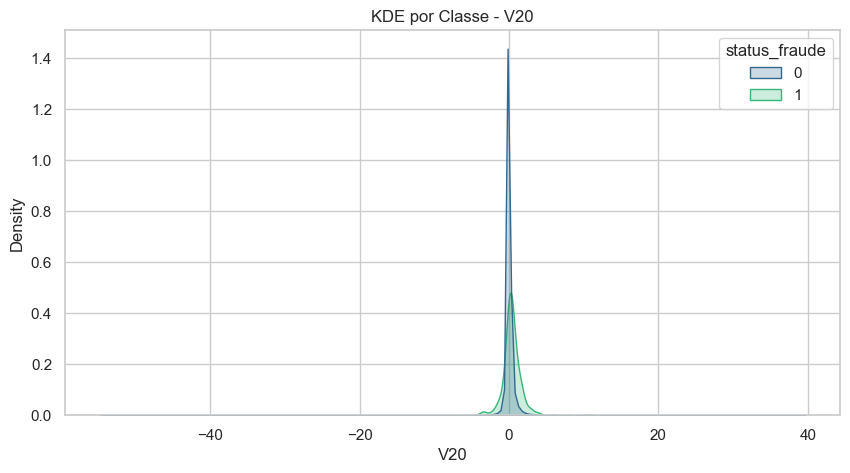

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


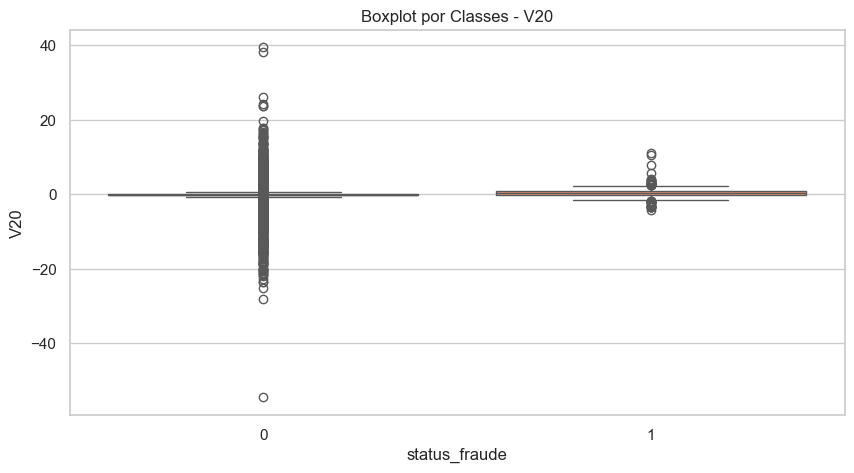

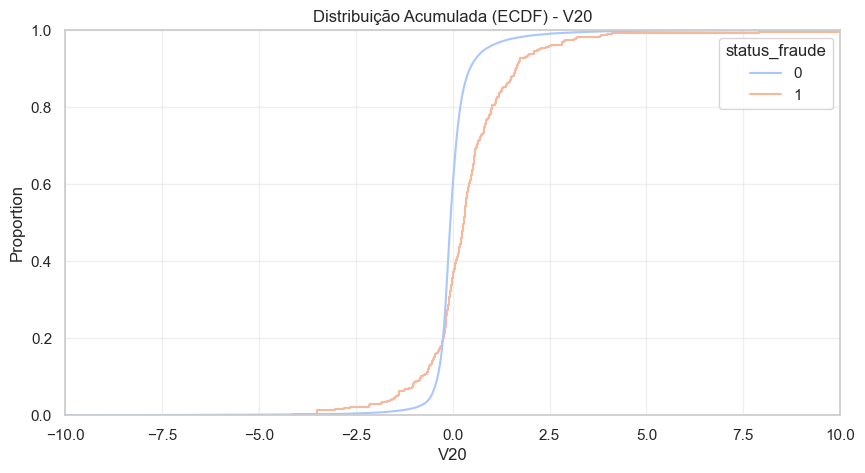

<Figure size 1000x500 with 0 Axes>

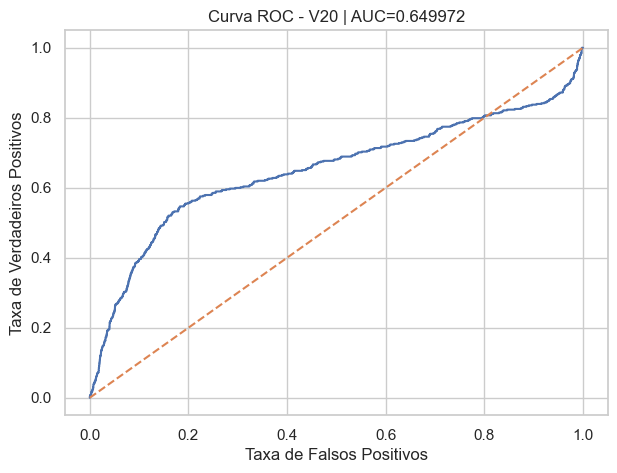

In [152]:
v20b = gerar_graficos_feature(
    df,
    feature='V20',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V21

#### a) Descritiva e Comparação com target 

In [153]:
v21a =  analisar_feature_flexivel(df, 'V21',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.734524
min         -34.830382
25%          -0.228395
50%          -0.029450
75%           0.186377
max          27.202839
Name: V21, dtype: object

[2] Dados faltantes em V21: 0


#### b) Análise Gráfica 

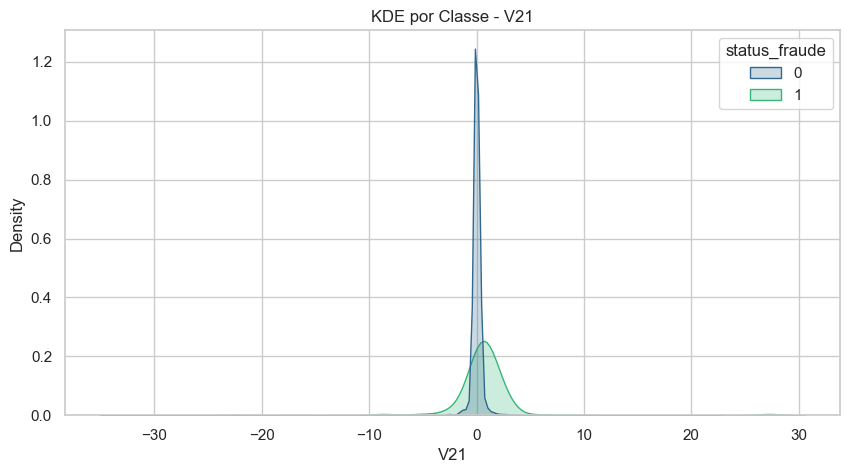

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


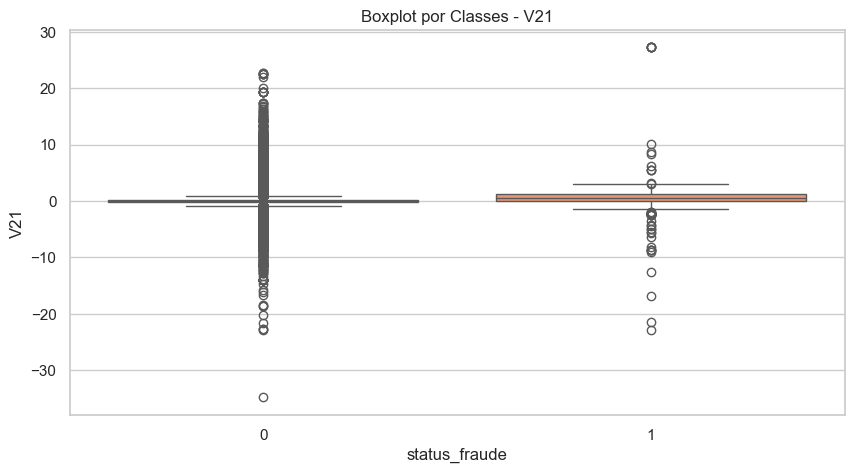

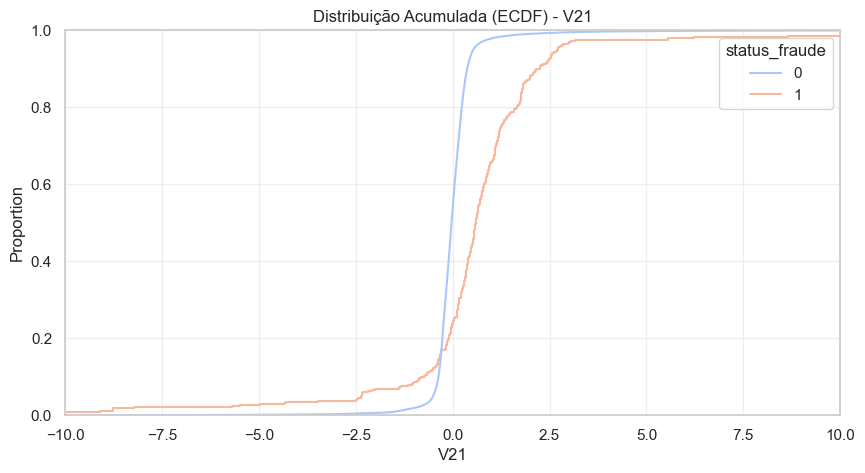

<Figure size 1000x500 with 0 Axes>

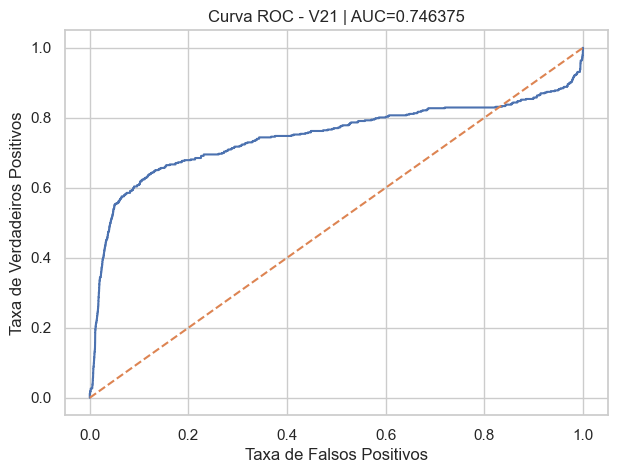

In [154]:
v21b = gerar_graficos_feature(
    df,
    feature='V21',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V22

#### a) Descritiva e Comparação com target 

In [155]:
v22a =  analisar_feature_flexivel(df, 'V22',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           0.725702
min         -10.933144
25%          -0.542350
50%           0.006782
75%           0.528554
max          10.503090
Name: V22, dtype: object

[2] Dados faltantes em V22: 0


#### b) Análise Gráfica 

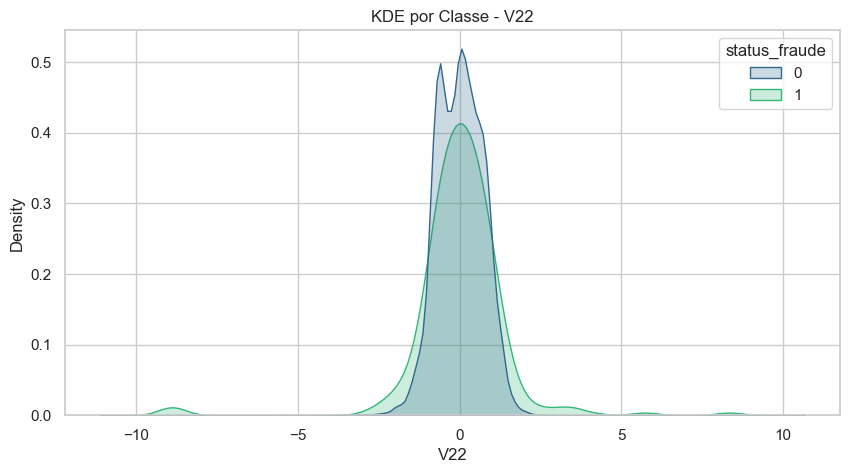

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


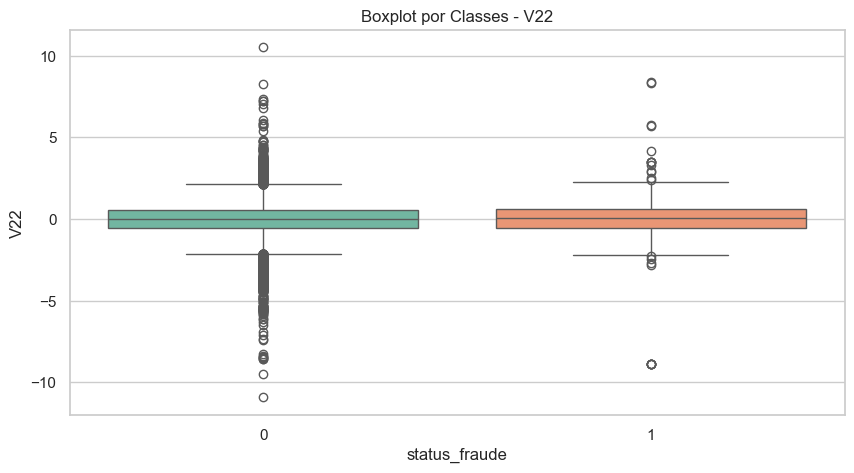

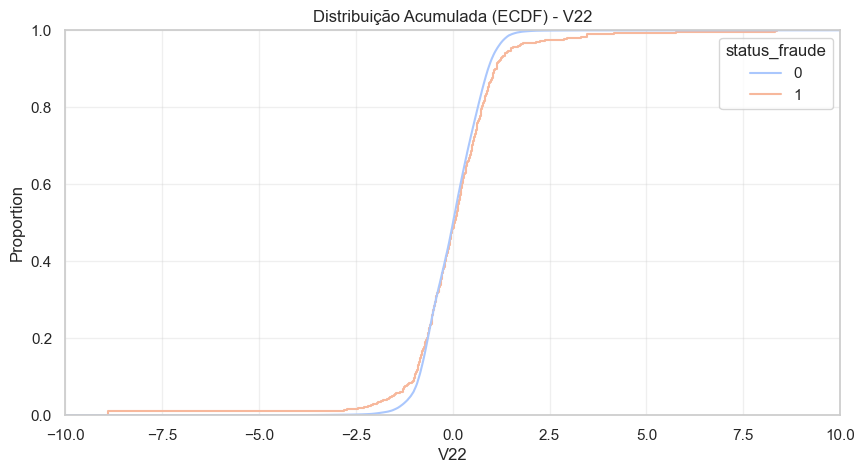

<Figure size 1000x500 with 0 Axes>

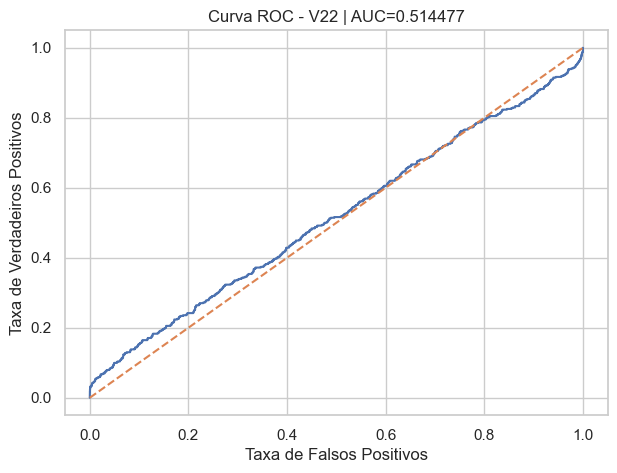

In [156]:
v22b = gerar_graficos_feature(
    df,
    feature='V22',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V23

#### a) Descritiva e Comparação com target 

In [157]:
v23a =  analisar_feature_flexivel(df, 'V23',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.624460
min         -44.807735
25%          -0.161846
50%          -0.011193
75%           0.147642
max          22.528412
Name: V23, dtype: object

[2] Dados faltantes em V23: 0


#### b) Análise Gráfica 

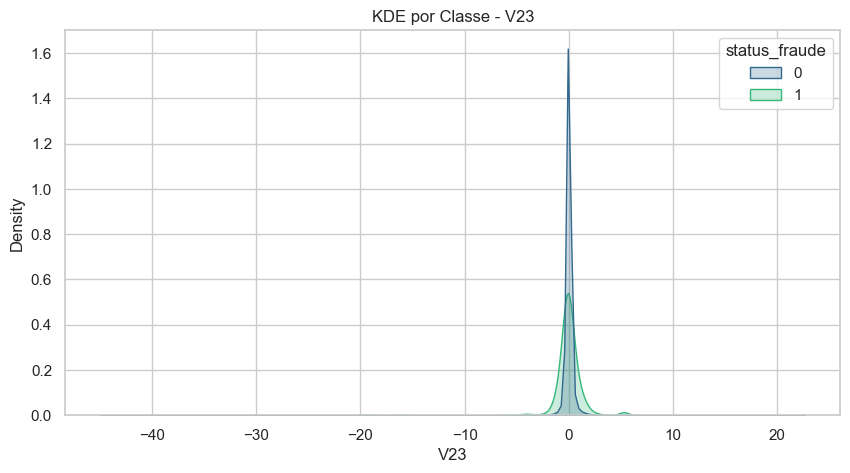

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


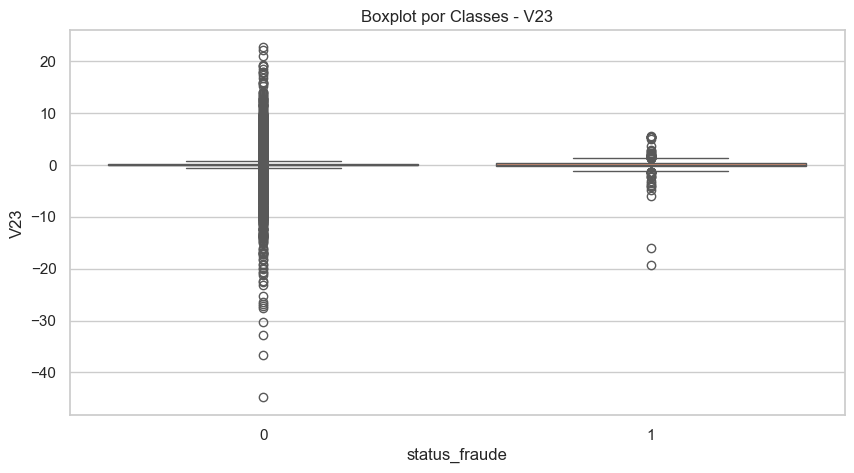

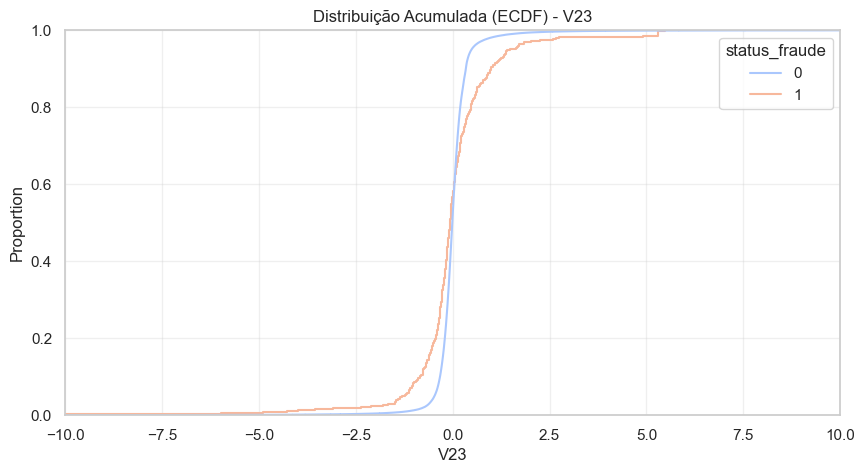

<Figure size 1000x500 with 0 Axes>

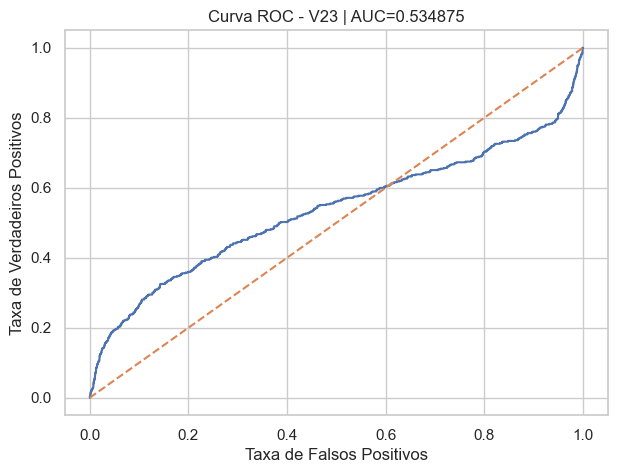

In [158]:
v23b = gerar_graficos_feature(
    df,
    feature='V23',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V24

#### a) Descritiva e Comparação com target 

In [159]:
v24a =  analisar_feature_flexivel(df, 'V24',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.605647
min          -2.836627
25%          -0.354586
50%           0.040976
75%           0.439527
max           4.584549
Name: V24, dtype: object

[2] Dados faltantes em V24: 0


#### b) Análise Gráfica 

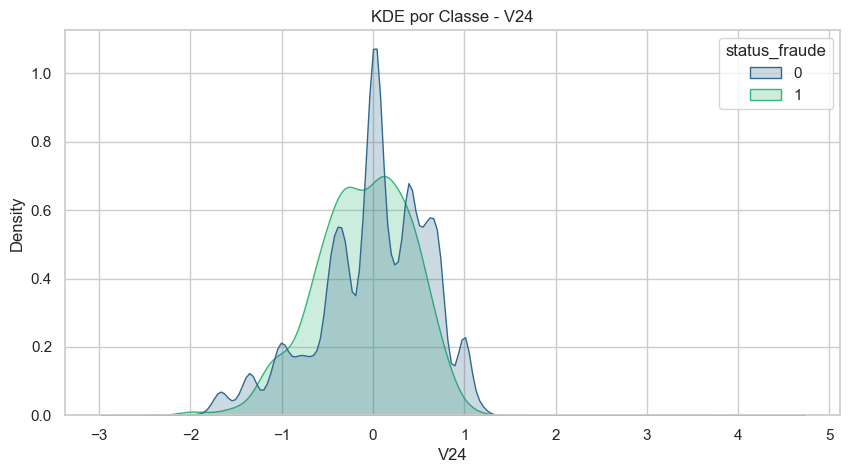

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


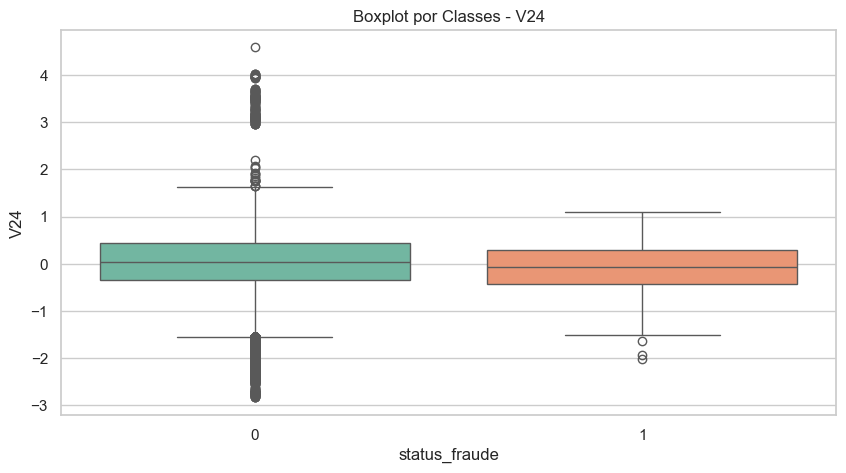

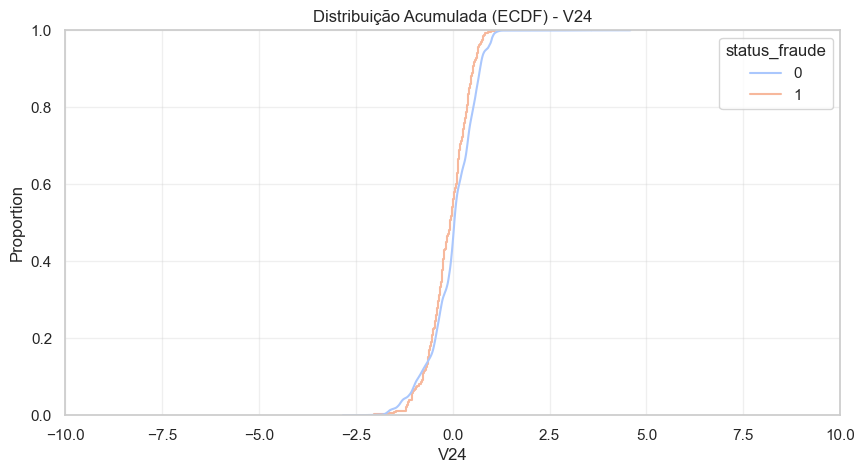

<Figure size 1000x500 with 0 Axes>

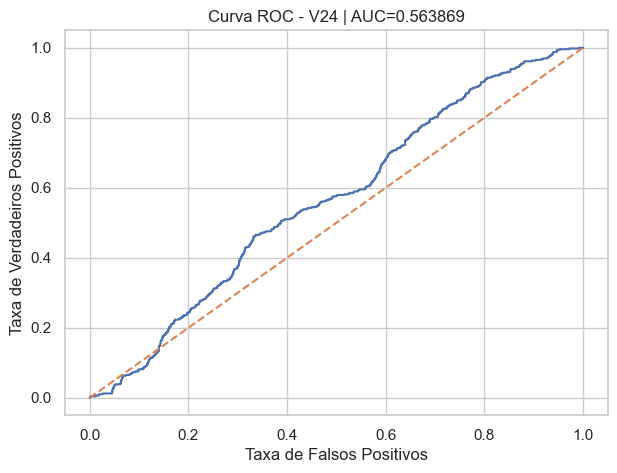

In [160]:
v24b = gerar_graficos_feature(
    df,
    feature='V24',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V25

#### a) Descritiva e Comparação com target 

In [161]:
v25a =  analisar_feature_flexivel(df, 'V25',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.521278
min         -10.295397
25%          -0.317145
50%           0.016594
75%           0.350716
max           7.519589
Name: V25, dtype: object

[2] Dados faltantes em V25: 0


#### b) Análise Gráfica 

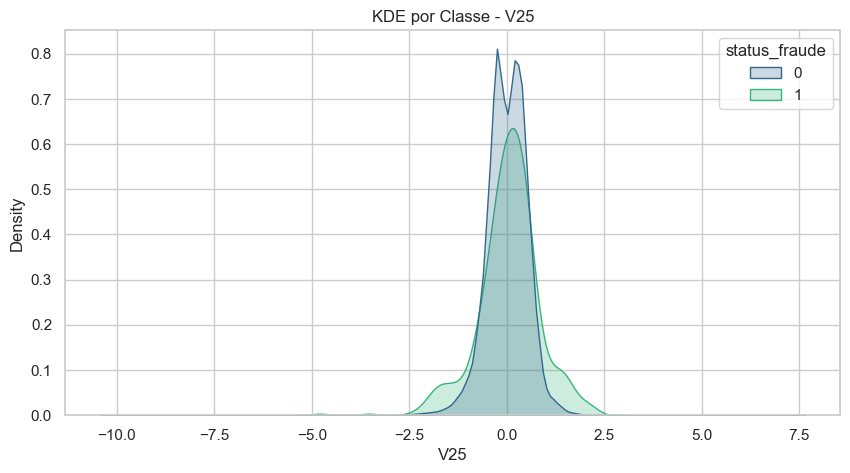

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


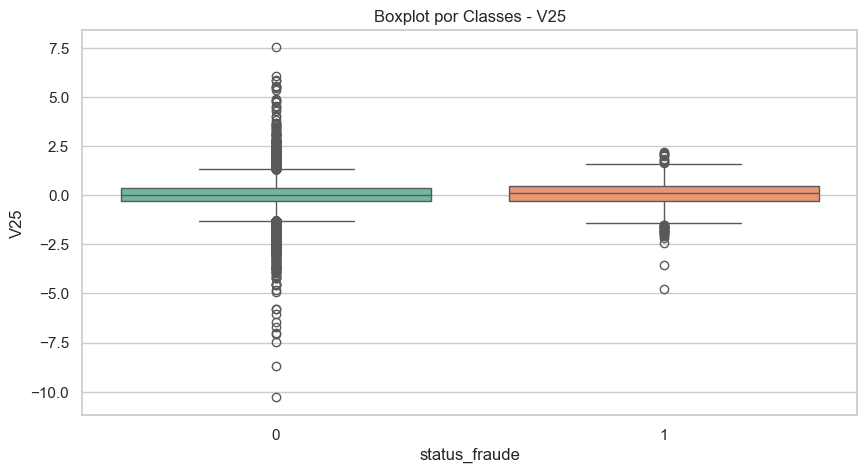

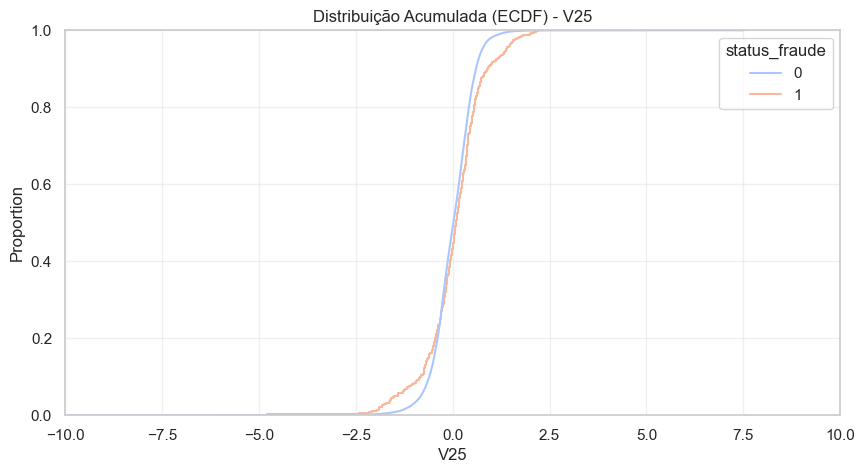

<Figure size 1000x500 with 0 Axes>

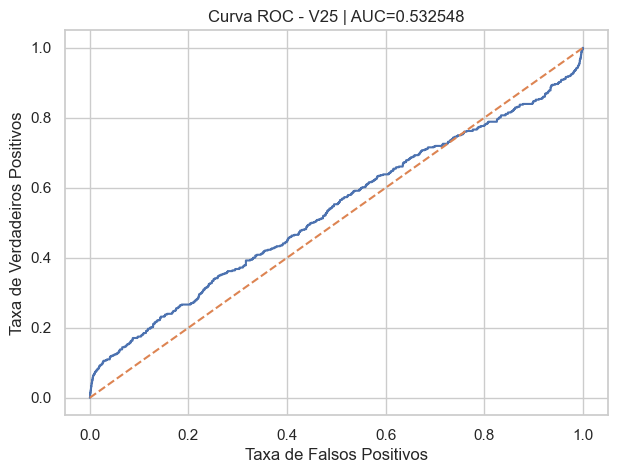

In [162]:
v25b = gerar_graficos_feature(
    df,
    feature='V25',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V26

#### a) Descritiva e Comparação com target 

In [163]:
v26a =  analisar_feature_flexivel(df, 'V26',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean          0.000000
std           0.482227
min          -2.604551
25%          -0.326984
50%          -0.052139
75%           0.240952
max           3.517346
Name: V26, dtype: object

[2] Dados faltantes em V26: 0


#### b) Análise Gráfica 

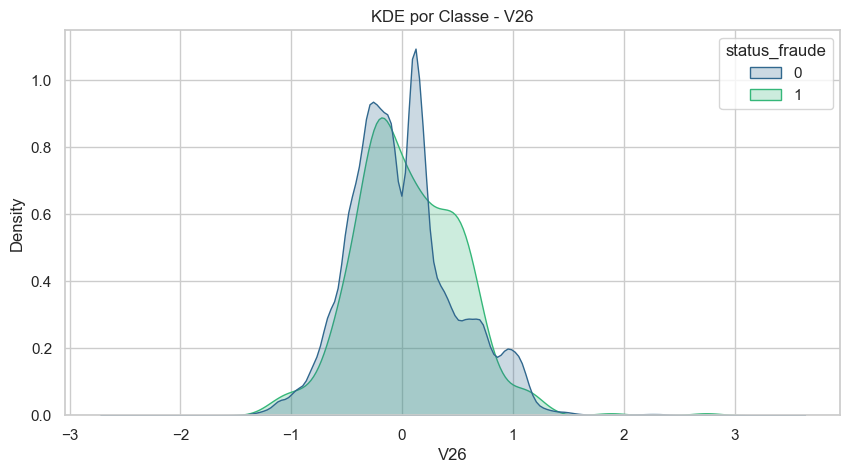

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


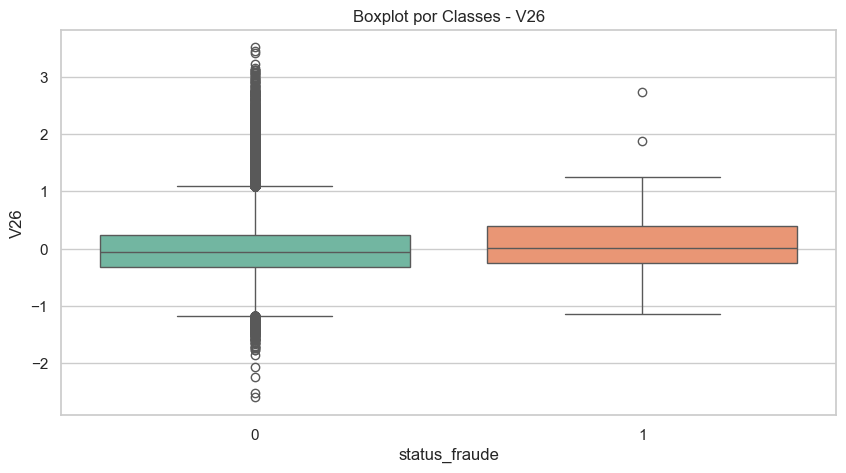

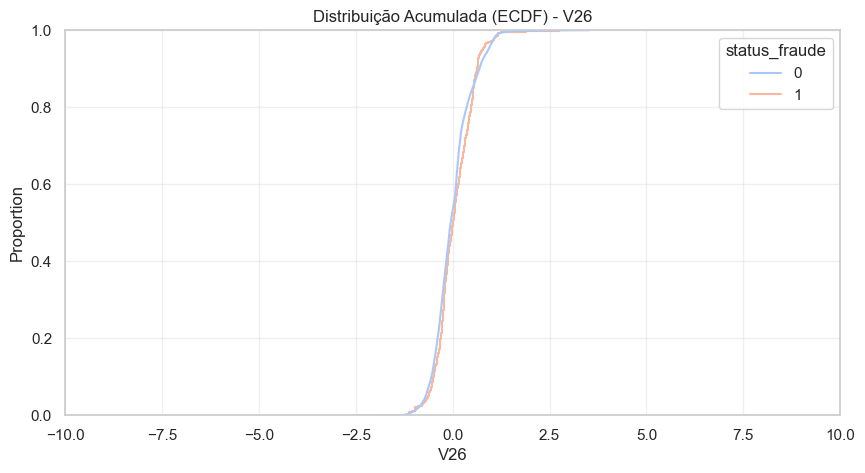

<Figure size 1000x500 with 0 Axes>

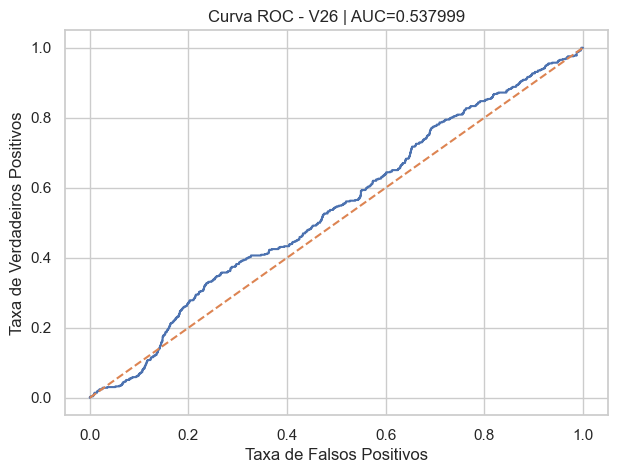

In [164]:
v26b = gerar_graficos_feature(
    df,
    feature='V26',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V27

#### a) Descritiva e Comparação com target 

In [165]:
v27a =  analisar_feature_flexivel(df, 'V27',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           0.403632
min         -22.565679
25%          -0.070840
50%           0.001342
75%           0.091045
max          31.612198
Name: V27, dtype: object

[2] Dados faltantes em V27: 0


#### b) Análise Gráfica 

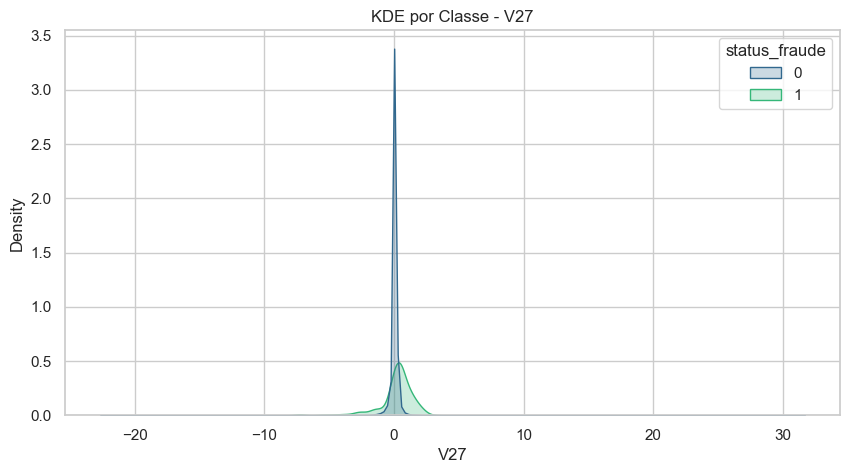

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


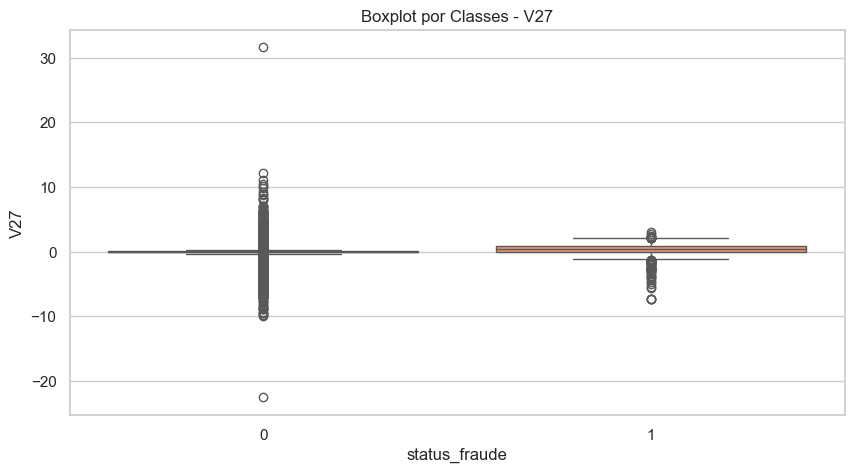

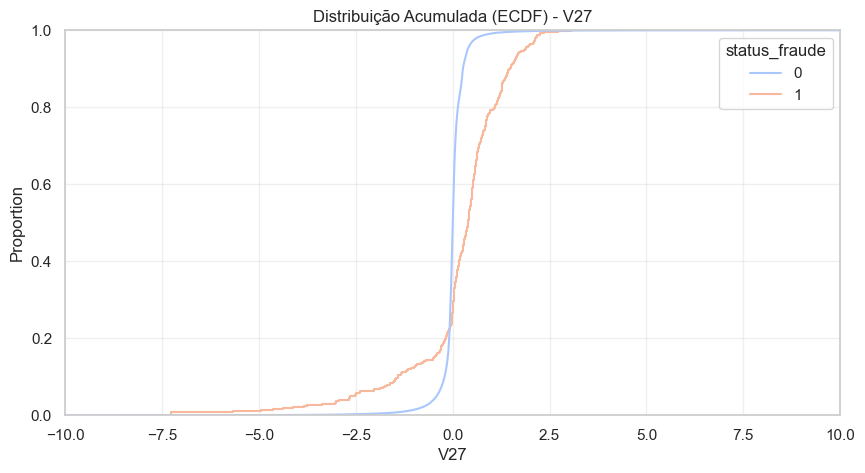

<Figure size 1000x500 with 0 Axes>

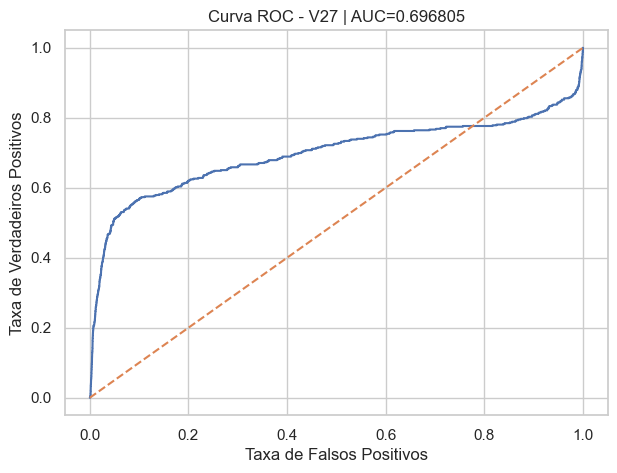

In [166]:
v27b = gerar_graficos_feature(
    df,
    feature='V27',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE V28

#### a) Descritiva e Comparação com target 

In [167]:
v28a =  analisar_feature_flexivel(df, 'V28',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         -0.000000
std           0.330083
min         -15.430084
25%          -0.052960
50%           0.011244
75%           0.078280
max          33.847808
Name: V28, dtype: object

[2] Dados faltantes em V28: 0


#### b) Análise Gráfica 

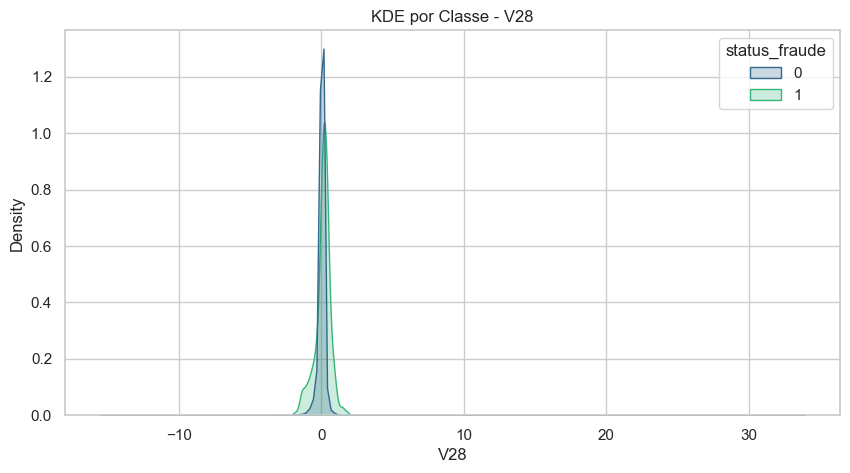

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


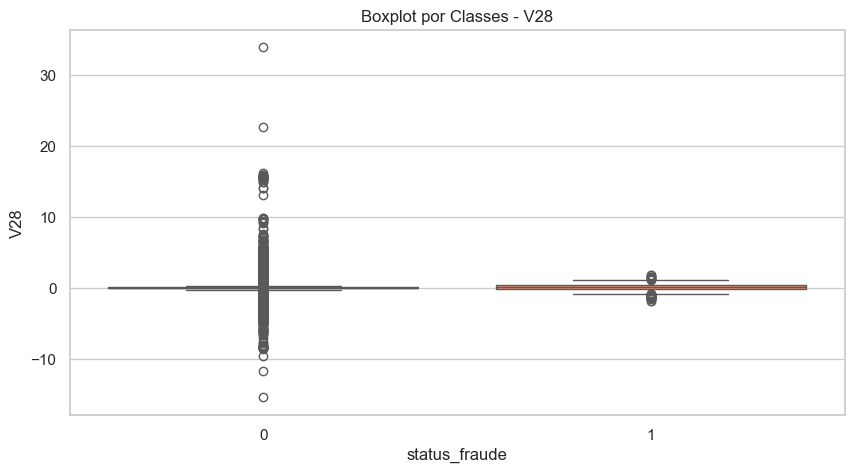

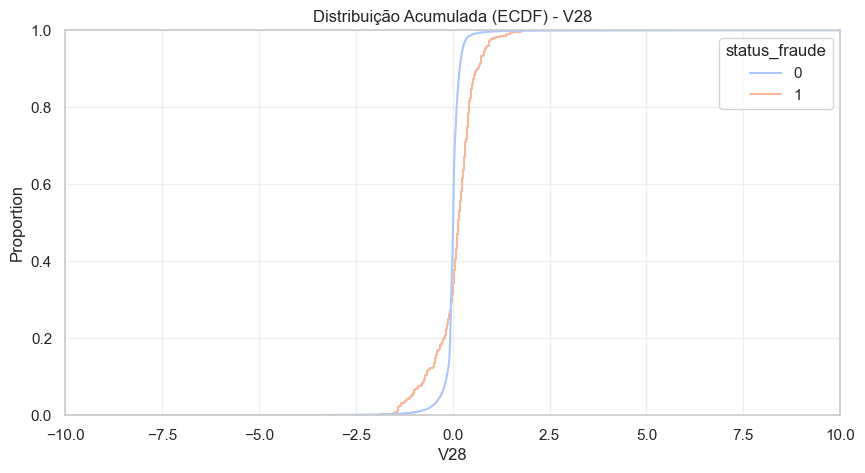

<Figure size 1000x500 with 0 Axes>

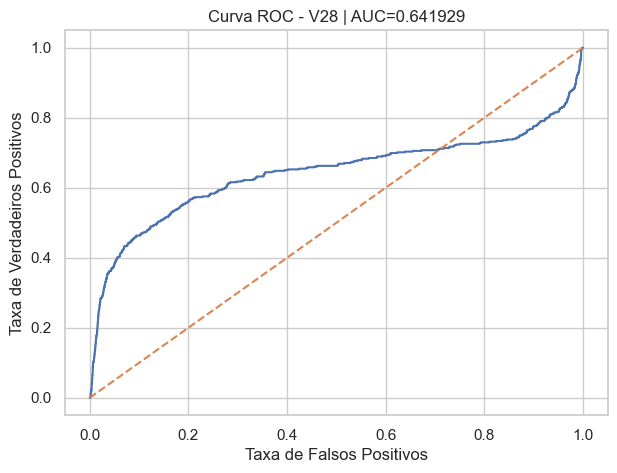

In [168]:
v28b = gerar_graficos_feature(
    df,
    feature='V28',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE tempo_desde_a_primeira_transacao

#### a) Descritiva e Comparação com target 

In [169]:
vsobre_tempoa =  analisar_feature_flexivel(df,'tempo_desde_a_primeira_transacao',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: tempo_desde_a_primeira_transacao, dtype: object

[2] Dados faltantes em tempo_desde_a_primeira_transacao: 0


#### b) Análise Gráfica 

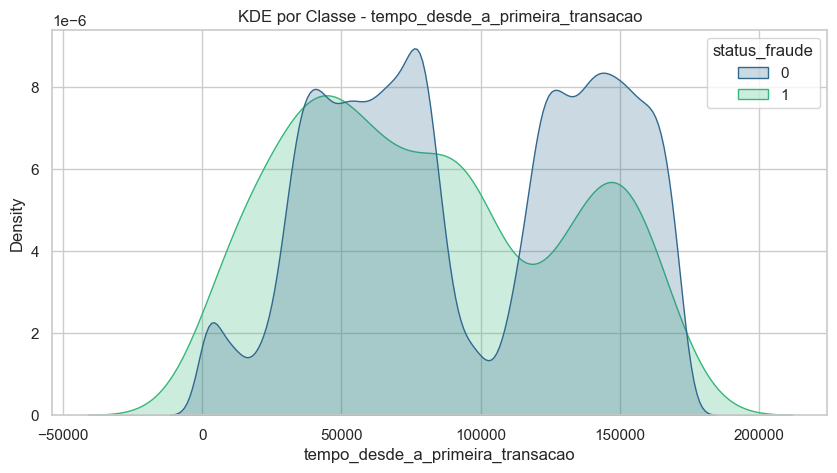

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


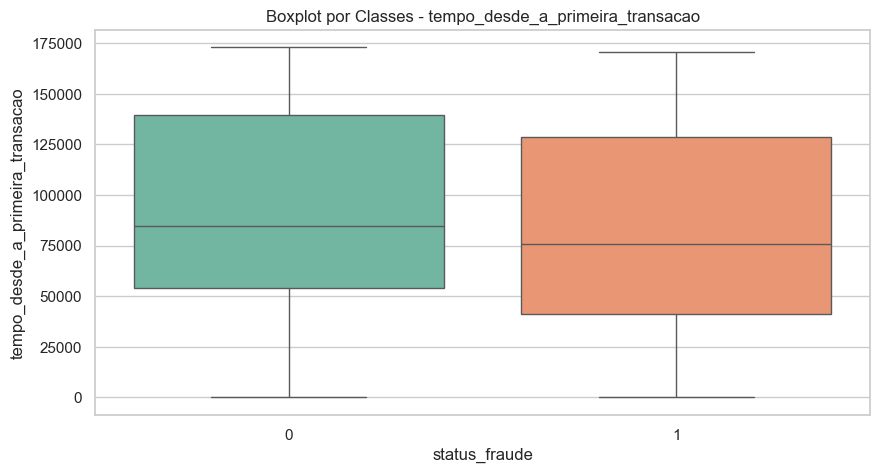

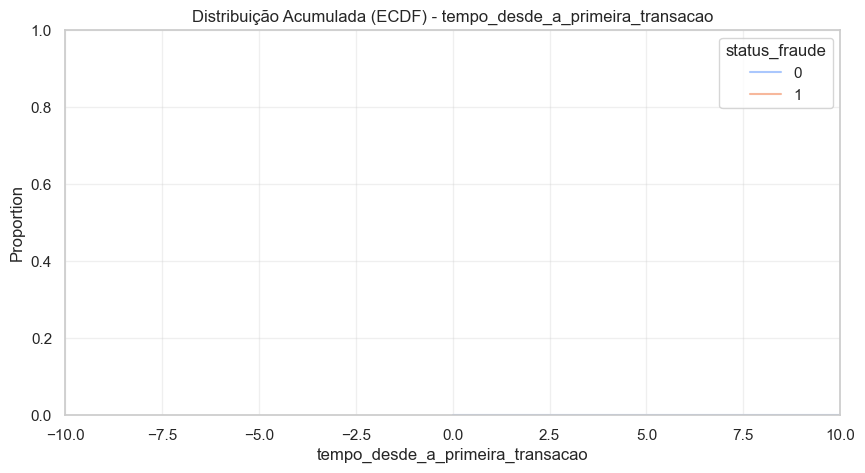

<Figure size 1000x500 with 0 Axes>

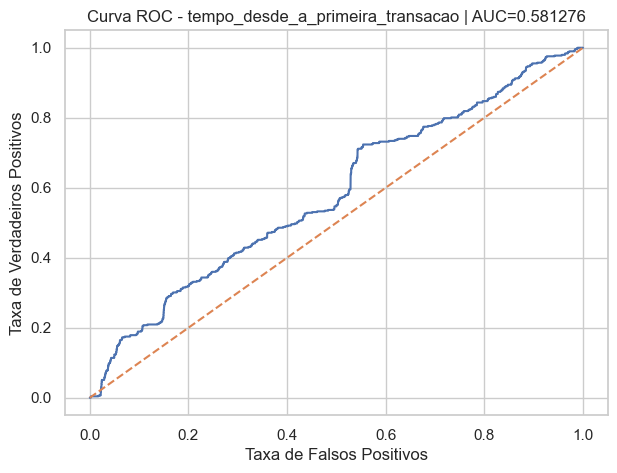

In [170]:
vsobreotempob = gerar_graficos_feature(
    df,
    feature='tempo_desde_a_primeira_transacao',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

### ESTUDO SOBRE valor_de_transacao	

#### a) Descritiva e Comparação com target 

In [171]:
vvalor_transcaoa =  analisar_feature_flexivel(df, 'valor_de_transacao',target_name='status_fraude', alpha=valor_alpha ,resumo_features=resumo_features)


[1] Medidas Descritivas:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: valor_de_transacao, dtype: object

[2] Dados faltantes em valor_de_transacao: 0


#### b) Análise Gráfica 

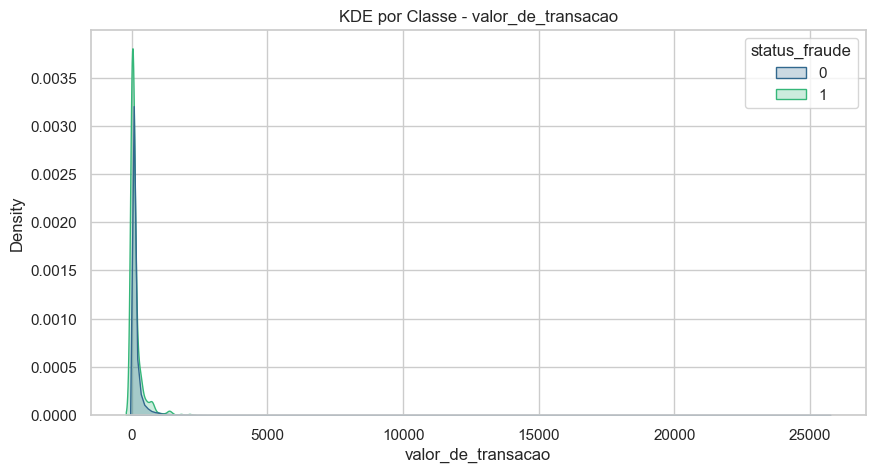

C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_12524\1634470343.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


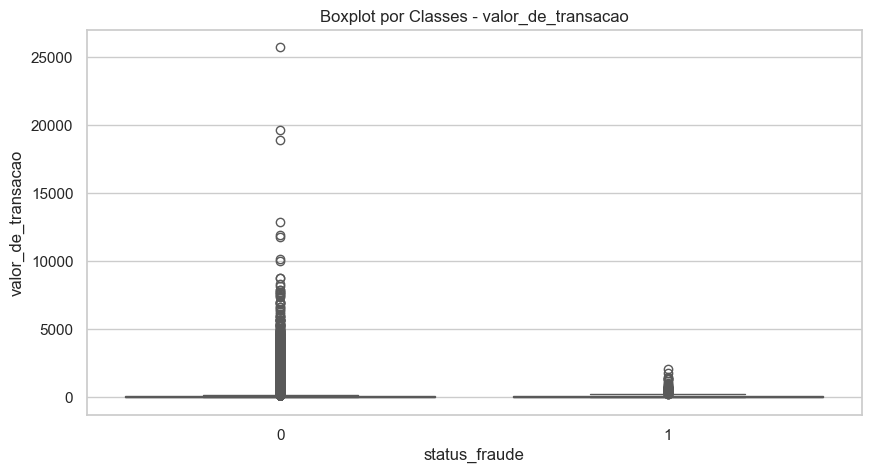

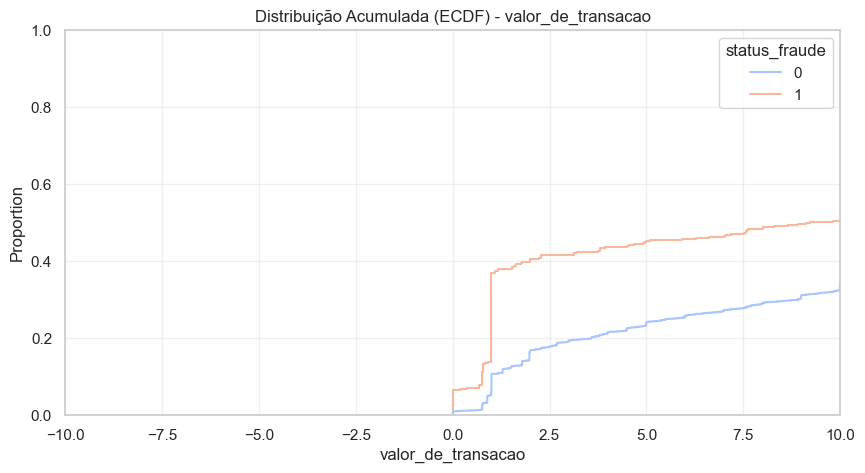

<Figure size 1000x500 with 0 Axes>

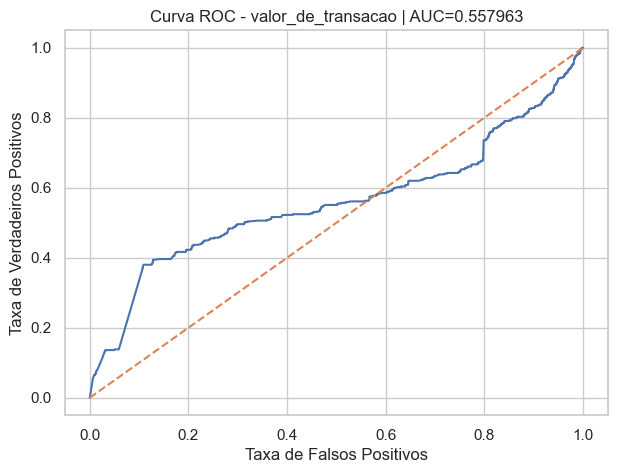

In [172]:
vvalor_transcaob = gerar_graficos_feature(
    df,
    feature='valor_de_transacao',
    coluna_alvo='status_fraude',
    xlim_hist=(-10, 10),
    xlim_box=(-10, 10),
    resumo_features=resumo_features
)

## TABELA INFORMACOES

In [173]:
df_resumo = pd.DataFrame(resumo_features)
display(df_resumo)
# Salva o DataFrame como CSV
df_resumo.to_csv('resumo_features.csv', index=False)


fim = time.time()
tempo_total = fim - inicio

print(f"Tempo de execução: {tempo_total:.4f} segundos, no 2.0")

,Feature,Normalidade,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Correlacao_spearman,inf_mutua,divergencia_kl,Curva ROC,KS,Wasser,Assimetria,Curtose
0,V1,0,7062,1.206170,1.740785e-113,-0.042424,0.002127,1.944821,0.794906,0.475331,4.781364,3.280650,32.486088
1,V2,0,13526,1.607088,1.650438e-163,0.051062,0.003228,6.078115,0.854955,0.633201,3.656017,4.624841,95.771404
2,V3,0,3363,3.467369,1.211048e-219,-0.059278,0.004952,7.229630,0.912073,0.703682,7.045619,2.240144,26.619062
3,V4,0,11148,2.966061,3.625904e-248,0.063045,0.004976,8.999220,0.938258,0.766404,4.550031,0.676289,2.635388
4,V5,0,12295,1.064668,3.053712e-58,-0.030147,0.002391,3.983812,0.709570,0.436442,3.291443,2.425889,206.900907
5,V6,0,22965,0.864308,2.231002e-93,-0.038410,0.002388,3.355636,0.767005,0.486425,1.447590,1.826571,42.641724
6,V7,0,8948,2.486101,1.464234e-146,-0.048308,0.003952,7.055373,0.835812,0.660578,5.595599,2.553894,405.600275
7,V8,0,24134,0.501918,8.509891e-34,0.022706,0.001898,2.915934,0.657842,0.368395,2.772945,8.521899,220.583080
8,V9,0,8283,1.964993,8.943723e-154,-0.049499,0.004277,3.828056,0.844090,0.576320,2.585589,0.554677,3.731224
9,V10,0,9496,4.120819,9.611131e-222,-0.059564,0.007530,11.218277,0.914057,0.804291,5.686707,1.187134,31.987656


Tempo de execução: 2245.7796 segundos, no 2.0
